# TCCT S94H R3 — Resumable Independent Confirmation

请选择 **Kernel → Restart Kernel and Run All Cells**。

每个场景完成后立即保存。已经完成的检查点会自动复用；断网、关闭页面或重启后可继续。最后一格只在 24 个检查点全部通过哈希和完整性验证后才导出正式证书。

本界面不搜索候选、不重新训练、不重新导出冻结候选，也不修改核心机制、规则、去重或无向冻结。


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
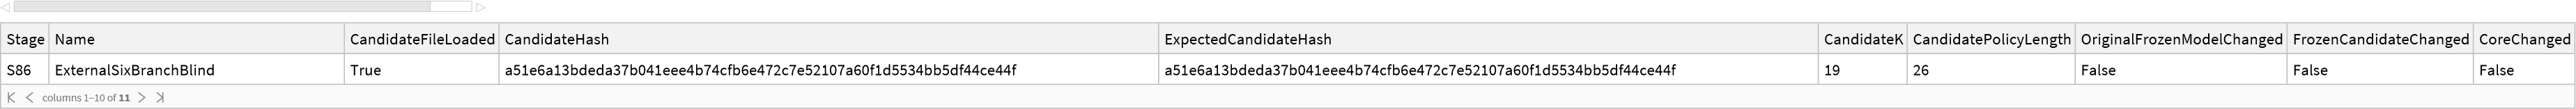

In [5]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]


Dataset[{<|Stage -> S94H, Name -> IndependentFullQueryConfirmation, AuditOnly -> True, 
 
>     DevelopmentOnly -> True, BlindTest -> False, PreflightPassed -> True, 
 
>     OriginalFrozenModelLocked -> True, S94AAuditLocked -> True, 
 
>     S94BResultLocked -> True, S94CDiagnosticArtifactsLocked -> True, 
 
>     S94DAuditLocked -> True, S94EAuditLocked -> True, S94FAuditLocked -> True, 
 
>     S94GDevelopmentLocked -> True, CoreChanged -> False, TrainingRunYet -> False, 
 
>     DevelopmentCasesGeneratedYet -> False, CandidateFrozen -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 18], 
 
>    1], <||>]
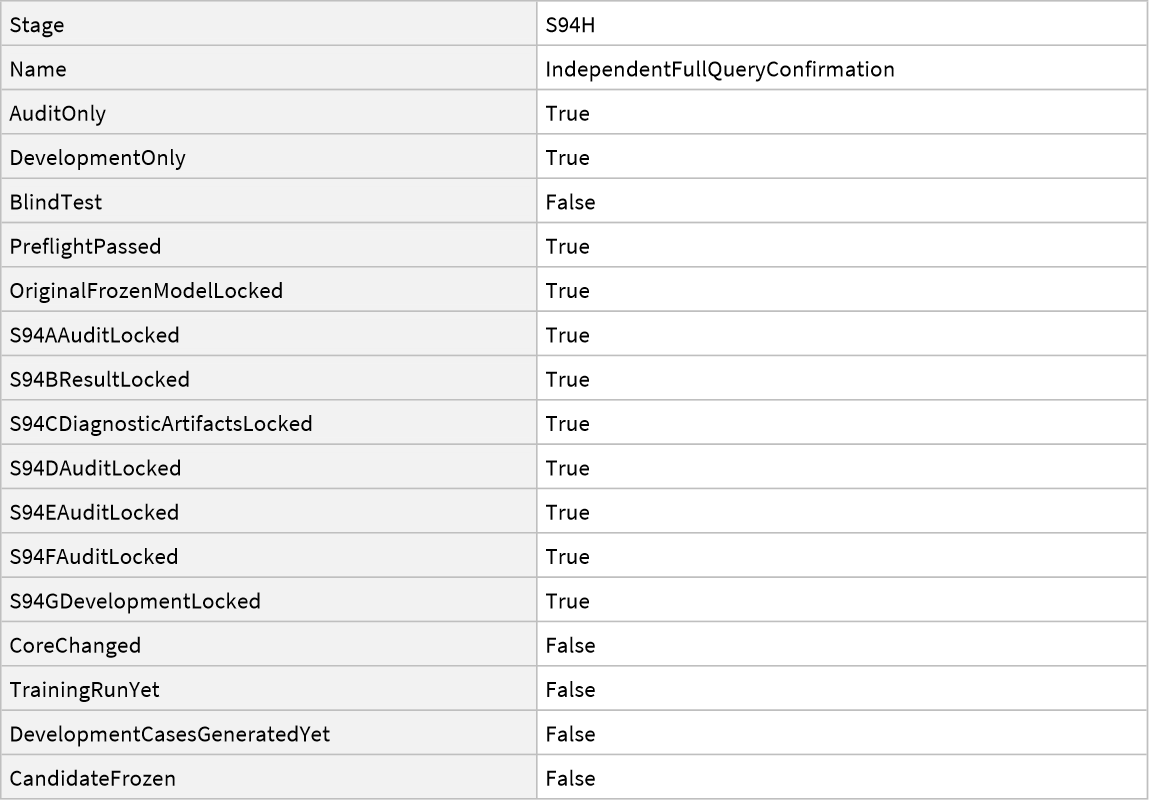

In [93]:
expectedFrozenModelHash94H=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash94H=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedK33CandidateFileHash94H=
"4a252b8977101d024b1b2feb00b4626ca28290c3982cdad199bc78ef7e0c98f1";
expectedBaseCandidateHash94H=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedBaseCandidateFileHash94H=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedBaseRuntimeFileHash94H=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedPairCandidateHash94H=
"540229035af53b2e014592fd7e7d2eab70b374844d9a73000026325c6cd39a1c";
expectedPairCandidateFileHash94H=
"aecbe544a4af3a8ad0ba0494bb11312dd4a4b71f1a1c7ae42489a5300c7078ff";
expectedPairRuntimeFileHash94H=
"74a926b8efccaddbd1dd07373ac35a93bc53e9fb08cc456ce1adb6a006d333c6";
expectedS94AAuditFileHash94H=
"ab0f6524f8cb8ee8edb915e132044734f8db8ce20758c09f26ded9de01571571";
expectedS94BResultHash94H=
"dc3de125d10d871c62857f051bbff204881512f63286bc0f3882791514724f9d";
expectedS94BCertificateFileHash94H=
"6b3c44566c80c88495f2a322a0763b7a188383445b554eefc30e7fa90b4e461f";
expectedS94BArtifactFileHash94H=
"998fa0de0fd8e14cf9c797287f64c824f7a435c2aa3c8b0b80b0a920075dc3e4";
expectedS94CDiagnosticResultHash94H=
"7b54af78cbef4204ceb006799d2650fd365f01ffad3dcf6de3194a8ffea0abfc";
expectedS94CCertificateFileHash94H=
"7281c001f977f6e8cc3c51b466bd7f48ce953a8465379e68116661ed8a7181e9";
expectedS94CArtifactFileHash94H=
"52aae85593e68fbc0bc8bd7ec1f1552e484e093156f334f65eff96b8889b6c7a";
expectedS94DResultHash94H=
"5d94413b21203c3b06dd661a972b6271b078163545d46a487963f58223951f83";
expectedS94DCertificateFileHash94H=
"2d6c529a13d5a7d8ccecf6d2ce19effcd6649d4a3cf74f62638d9f7f2f64b2ad";
expectedS94EResultHash94H=
"88cb2d459d7eb30eca1a18a9df0be07b1702a7a5e5387fdd35767adb34fff5e6";
expectedS94ECertificateFileHash94H=
"278c0340332e7dcb60b1bf3a07f06f0d8a8ce77bf231f3dfbce718a189fb9a6f";
expectedS94FResultHash94H=
"980fcc8a39a23795e8206560a9bb6c2a357f57ac1e041f2e10d89caa6d6a2fa1";
expectedS94FCertificateFileHash94H=
"ce776f1959926f3e81584dd10f34ee675fc90a07a7d44b3915583cd5050e6e20";
expectedS94GResultHash94H=
"d1c1ad6fc51b6545246146556c7c48aa635d66589c138997743d8b9f6151a46b";
expectedS94GCertificateFileHash94H=
"cbb4c1331e8055ad9806bbc870a25cefb65c457abb54d3d506edc48ba04fefed";
expectedS94GArtifactFileHash94H=
"21d84fe268a1a61cb1e13c2f457144564cc79569aa7d1fbefc3a4e5fa4a221f4";

k33CandidatePath94H="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
baseRuntimePath94H="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
baseCandidatePath94H="E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
pairRuntimePath94H="E:/engine_wolf/TCCT_S92B_PairedContrastDecoderRuntime.wl";
pairCandidatePath94H="E:/engine_wolf/TCCT_S92B_FrozenPairedContrastDecoder.wxf";
s94aAuditPath94H="E:/engine_wolf/TCCT_S94A_ModulusFeasibilityAudit.json";
s94bCertificatePath94H="E:/engine_wolf/TCCT_S94B_RoleAwareReadoutDevelopment.json";
s94bArtifactPath94H="E:/engine_wolf/TCCT_S94B_RoleAwareDevelopmentPairs.wxf";
s94cDiagnosticCertificatePath94H="E:/engine_wolf/TCCT_S94C_ExpandedRoleAwareReadoutDevelopment.json";
s94cDiagnosticArtifactPath94H="E:/engine_wolf/TCCT_S94C_ExpandedRoleAwareDevelopmentPairs.wxf";
s94dAuditPath94H="E:/engine_wolf/TCCT_S94D_RepresentationSufficiencyAudit.json";
s94eAuditPath94H="E:/engine_wolf/TCCT_S94E_RelationBindingFeasibilityAudit.json";
s94fAuditPath94H="E:/engine_wolf/TCCT_S94F_DualChannelInformationAudit.json";
s94gCertificatePath94H="E:/engine_wolf/TCCT_S94G_FullQueryScopeDevelopment.json";
s94gArtifactPath94H="E:/engine_wolf/TCCT_S94G_FullQueryScopeDevelopmentPairs.wxf";
frozenCandidatePath94H="E:/engine_wolf/TCCT_S94H_FrozenFullQueryReadout.wxf";
resultCertificatePath94H="E:/engine_wolf/TCCT_S94H_IndependentFullQueryConfirmation.json";

ClearAll[FileSHA256Hex94H,CoreDefinitionBundle94H,
PairRuntimeDefinitionBundle94H];
FileSHA256Hex94H[path_String]:=If[FileExistsQ[path],
IntegerString[FileHash[path,"SHA256"],16,64],Missing["FileMissing",path]];
CoreDefinitionBundle94H[]:=CoreDefinitionBundle86[];
PairRuntimeDefinitionBundle94H[]:={DownValues[TCCTPairContrastVectorS92B],
DownValues[TCCTLoadFrozenPairDecoderS92B],
DownValues[TCCTPredictOrderedPairVectorsS92B],
DownValues[TCCTPredictOrderedPairWorldsS92B]};

requiredFiles94H={k33CandidatePath94H,baseRuntimePath94H,
baseCandidatePath94H,pairRuntimePath94H,pairCandidatePath94H,s94aAuditPath94H,
s94bCertificatePath94H,s94bArtifactPath94H,
s94cDiagnosticCertificatePath94H,s94cDiagnosticArtifactPath94H,
s94dAuditPath94H,s94eAuditPath94H,s94fAuditPath94H,
s94gCertificatePath94H,s94gArtifactPath94H};
If[!And@@(FileExistsQ/@requiredFiles94H),
Print["S94H aborted: one or more locked inputs are missing."];
Dataset[AssociationThread[requiredFiles94H,FileExistsQ/@requiredFiles94H]];Abort[]];
If[FileExistsQ[resultCertificatePath94H]&&
FileByteCount[resultCertificatePath94H]>0,
Print["S94H aborted: a prior development certificate exists. Preserve it."];Abort[]];
expectedFrozenCandidateObjectHash94H=
"5ec0e4eb89e9bb447a1e103537c7b4a82eab0c807023cd5862048372efdb418b";
expectedFrozenCandidateFileHash94H=
"8cbf7184200c6a04072f9b375af3137534dc3764bff7a32bf57db4a320187e1e";
If[!FileExistsQ[frozenCandidatePath94H]||FileByteCount[frozenCandidatePath94H]<=0,
Print["S94H recovery aborted: the previously frozen candidate is missing."];Abort[]];
If[!SameQ[FileSHA256Hex94H[frozenCandidatePath94H],
expectedFrozenCandidateFileHash94H],
Print["S94H recovery aborted: frozen candidate file hash mismatch."];Abort[]];

fileHashesBefore94H=FileSHA256Hex94H/@requiredFiles94H;
Clear[frozenCandidate86E];Get[k33CandidatePath94H];
k33HashLoaded94H=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
Get[baseRuntimePath94H];
baseDecoderLoaded94H=Quiet@Check[
TCCTLoadFrozenDecoderS87D[baseCandidatePath94H],$Failed];
baseDecoderRaw94H=If[AssociationQ[baseDecoderLoaded94H],
KeyDrop[baseDecoderLoaded94H,{"Classifier"}],$Failed];
Get[pairRuntimePath94H];
pairDecoderLoaded94H=Quiet@Check[
TCCTLoadFrozenPairDecoderS92B[pairCandidatePath94H],$Failed];
pairDecoderRaw94H=If[AssociationQ[pairDecoderLoaded94H],
KeyDrop[pairDecoderLoaded94H,{"Policy"}],$Failed];
s94aAudit94H=Quiet@Check[Import[s94aAuditPath94H,"RawJSON"],$Failed];
s94bCertificate94H=Quiet@Check[Import[s94bCertificatePath94H,"RawJSON"],$Failed];
s94cDiagnosticCertificate94H=Quiet@Check[
Import[s94cDiagnosticCertificatePath94H,"RawJSON"],$Failed];
s94cDiagnosticArtifact94H=Quiet@Check[
Import[s94cDiagnosticArtifactPath94H,"WXF"],$Failed];
s94dAudit94H=Quiet@Check[Import[s94dAuditPath94H,"RawJSON"],$Failed];
s94eAudit94H=Quiet@Check[Import[s94eAuditPath94H,"RawJSON"],$Failed];
s94fAudit94H=Quiet@Check[Import[s94fAuditPath94H,"RawJSON"],$Failed];
s94gCertificate94H=Quiet@Check[Import[s94gCertificatePath94H,"RawJSON"],$Failed];
s94gArtifact94H=Quiet@Check[Import[s94gArtifactPath94H,"WXF"],$Failed];

modelHashBefore94H=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashBefore94H=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
baseDecoderObjectHashBefore94H=Hash[Normal[baseDecoderRaw94H],"SHA256","HexString"];
pairDecoderObjectHashBefore94H=Hash[Normal[pairDecoderRaw94H],"SHA256","HexString"];
coreHashBefore94H=Hash[CoreDefinitionBundle94H[],"SHA256","HexString"];
canonicalizerHashBefore94H=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},
"SHA256","HexString"];
interventionHashBefore94H=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashBefore94H=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"];
baseRuntimeDefinitionHashBefore94H=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
pairRuntimeDefinitionHashBefore94H=Hash[
PairRuntimeDefinitionBundle94H[],"SHA256","HexString"];

preflightPassed94H=And[
SameQ[modelHashBefore94H,expectedFrozenModelHash94H],
SameQ[k33HashLoaded94H,expectedK33CandidateHash94H],
SameQ[fileHashesBefore94H[[1]],expectedK33CandidateFileHash94H],
AssociationQ[baseDecoderLoaded94H],
SameQ[baseDecoderRaw94H["CandidateHash"],expectedBaseCandidateHash94H],
SameQ[fileHashesBefore94H[[2]],expectedBaseRuntimeFileHash94H],
SameQ[fileHashesBefore94H[[3]],expectedBaseCandidateFileHash94H],
AssociationQ[pairDecoderLoaded94H],
SameQ[pairDecoderRaw94H["CandidateHash"],expectedPairCandidateHash94H],
SameQ[fileHashesBefore94H[[4]],expectedPairRuntimeFileHash94H],
SameQ[fileHashesBefore94H[[5]],expectedPairCandidateFileHash94H],
SameQ[fileHashesBefore94H[[6]],expectedS94AAuditFileHash94H],
AssociationQ[s94aAudit94H],
TrueQ[s94aAudit94H["AuditValidityPassed"]],
SameQ[s94aAudit94H["Outcome"],
"S94A_AUDIT_PASS_MODULUS_ALONE_INSUFFICIENT"],
SameQ[s94aAudit94H["CandidateHash"],expectedPairCandidateHash94H],
SameQ[fileHashesBefore94H[[7]],expectedS94BCertificateFileHash94H],
SameQ[fileHashesBefore94H[[8]],expectedS94BArtifactFileHash94H],
AssociationQ[s94bCertificate94H],
SameQ[s94bCertificate94H["ResultHash"],expectedS94BResultHash94H],
SameQ[s94bCertificate94H["Outcome"],"S94B_ROLE_AWARE_PARTIAL_IMPROVEMENT"],
TrueQ[s94bCertificate94H["TestValidityPassed"]],
TrueQ[s94bCertificate94H["IntegrityPassed"]],
SameQ[fileHashesBefore94H[[9]],expectedS94CCertificateFileHash94H],
SameQ[fileHashesBefore94H[[10]],expectedS94CArtifactFileHash94H],
AssociationQ[s94cDiagnosticCertificate94H],
AssociationQ[s94cDiagnosticArtifact94H],
SameQ[s94cDiagnosticCertificate94H["ResultHash"],
expectedS94CDiagnosticResultHash94H],
SameQ[s94cDiagnosticCertificate94H["Outcome"],
"S94C_EXPANDED_ROLE_AWARE_PARTIAL_IMPROVEMENT"],
TrueQ[s94cDiagnosticCertificate94H["TestValidityPassed"]],
TrueQ[s94cDiagnosticCertificate94H["IntegrityPassed"]],
SameQ[s94cDiagnosticCertificate94H["DevelopmentArtifactFileHash"],
expectedS94CArtifactFileHash94H],
SameQ[fileHashesBefore94H[[11]],expectedS94DCertificateFileHash94H],
AssociationQ[s94dAudit94H],
SameQ[s94dAudit94H["ResultHash"],expectedS94DResultHash94H],
SameQ[s94dAudit94H["Outcome"],"S94D_AUDIT_PASS_LOSS_STAGE_IDENTIFIED"],
TrueQ[s94dAudit94H["PreflightPassed"]],
TrueQ[s94dAudit94H["AuditValidityPassed"]],
TrueQ[s94dAudit94H["IntegrityPassed"]],
SameQ[fileHashesBefore94H[[12]],expectedS94ECertificateFileHash94H],
AssociationQ[s94eAudit94H],
SameQ[s94eAudit94H["ResultHash"],expectedS94EResultHash94H],
SameQ[s94eAudit94H["Outcome"],"S94E_RELATION_BINDING_HYPOTHESIS_REJECTED"],
TrueQ[s94eAudit94H["PreflightPassed"]],
TrueQ[s94eAudit94H["AuditValidityPassed"]],
TrueQ[s94eAudit94H["IntegrityPassed"]],
SameQ[fileHashesBefore94H[[13]],expectedS94FCertificateFileHash94H],
AssociationQ[s94fAudit94H],
SameQ[s94fAudit94H["ResultHash"],expectedS94FResultHash94H],
SameQ[s94fAudit94H["Outcome"],"S94F_AUDIT_PASS_CHANNEL_LOCALIZED"],
SameQ[s94fAudit94H["DominantDiagnosis"],
"OBSERVATION_SCOPE_LOSS_TOKEN_SURVIVES_OUTSIDE_REJECTS"],
TrueQ[s94fAudit94H["PreflightPassed"]],
TrueQ[s94fAudit94H["AuditValidityPassed"]],
TrueQ[s94fAudit94H["IntegrityPassed"]],
SameQ[fileHashesBefore94H[[14]],expectedS94GCertificateFileHash94H],
SameQ[fileHashesBefore94H[[15]],expectedS94GArtifactFileHash94H],
AssociationQ[s94gCertificate94H],AssociationQ[s94gArtifact94H],
SameQ[s94gCertificate94H["ResultHash"],expectedS94GResultHash94H],
SameQ[s94gCertificate94H["Outcome"],"S94G_FULL_QUERY_SCOPE_DEVELOPMENT_PASS"],
TrueQ[s94gCertificate94H["DevelopmentCriterionPassed"]],
TrueQ[s94gCertificate94H["TestValidityPassed"]],
TrueQ[s94gCertificate94H["IntegrityPassed"]],
SameQ[s94gCertificate94H["DevelopmentArtifactFileHash"],
expectedS94GArtifactFileHash94H]];

preflight94H=<|"Stage"->"S94H","Name"->"IndependentFullQueryConfirmation",
"AuditOnly"->True,"DevelopmentOnly"->True,"BlindTest"->False,
"PreflightPassed"->preflightPassed94H,
"OriginalFrozenModelLocked"->SameQ[modelHashBefore94H,expectedFrozenModelHash94H],
"S94AAuditLocked"->SameQ[fileHashesBefore94H[[6]],expectedS94AAuditFileHash94H],
"S94BResultLocked"->SameQ[fileHashesBefore94H[[7]],expectedS94BCertificateFileHash94H],
"S94CDiagnosticArtifactsLocked"->And[
SameQ[fileHashesBefore94H[[9]],expectedS94CCertificateFileHash94H],
SameQ[fileHashesBefore94H[[10]],expectedS94CArtifactFileHash94H]],
"S94DAuditLocked"->SameQ[fileHashesBefore94H[[11]],
expectedS94DCertificateFileHash94H],
"S94EAuditLocked"->SameQ[fileHashesBefore94H[[12]],
expectedS94ECertificateFileHash94H],
"S94FAuditLocked"->SameQ[fileHashesBefore94H[[13]],
expectedS94FCertificateFileHash94H],
"S94GDevelopmentLocked"->And[
SameQ[fileHashesBefore94H[[14]],expectedS94GCertificateFileHash94H],
SameQ[fileHashesBefore94H[[15]],expectedS94GArtifactFileHash94H]],
"CoreChanged"->False,"TrainingRunYet"->False,
"DevelopmentCasesGeneratedYet"->False,"CandidateFrozen"->False|>;
If[!TrueQ[preflightPassed94H],Print[Dataset[{preflight94H}]];
Print["S94H aborted: locked-input preflight failed."];Abort[]];
Dataset[{preflight94H}]


Dataset[{<|Stage -> S94H, Name -> FullQueryScopeDevelopment, DevelopmentOnly -> True, 
 
>     BlindTest -> False, UsesRevealedS94Labels -> True, Pairs -> 416, 
 
>     WorldsReplayed -> 832, Folds -> 55, 
 
>     Representations -> 
 
>      {SlotRaw12, SlotTokenOneHot396, RelationNumeric60, RelationDeltaOneHot396, 
 
>       Combined804}, AntisymmetryConstraint -> Score[x,y]==-Score[y,x], 
 
>     DevelopmentPassAccuracy -> 0.95, DevelopmentPassWorstFoldAccuracy -> 0.8, 
 
>     CandidateFrozen -> False, CoreMechanismChanged -> False, 
 
>     ProtocolHash -> 2076ed436f04851deddf94751c4be37018204c639637d245277da221818ffa9e, 
 
>     TestDefinitionHash -> 
 
>      11c6b838994aa3d235f1bd4605be23dd148b43cccc96a4ff3ddafeb38fb06007, 
 
>     ReadoutDefinitionHash -> 
 
>      e4058fcbee54b6a98e1b52ae676f16451e29d95f16225c415a6582ea5e1f22db|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 17], 
 
>    1], <||>]
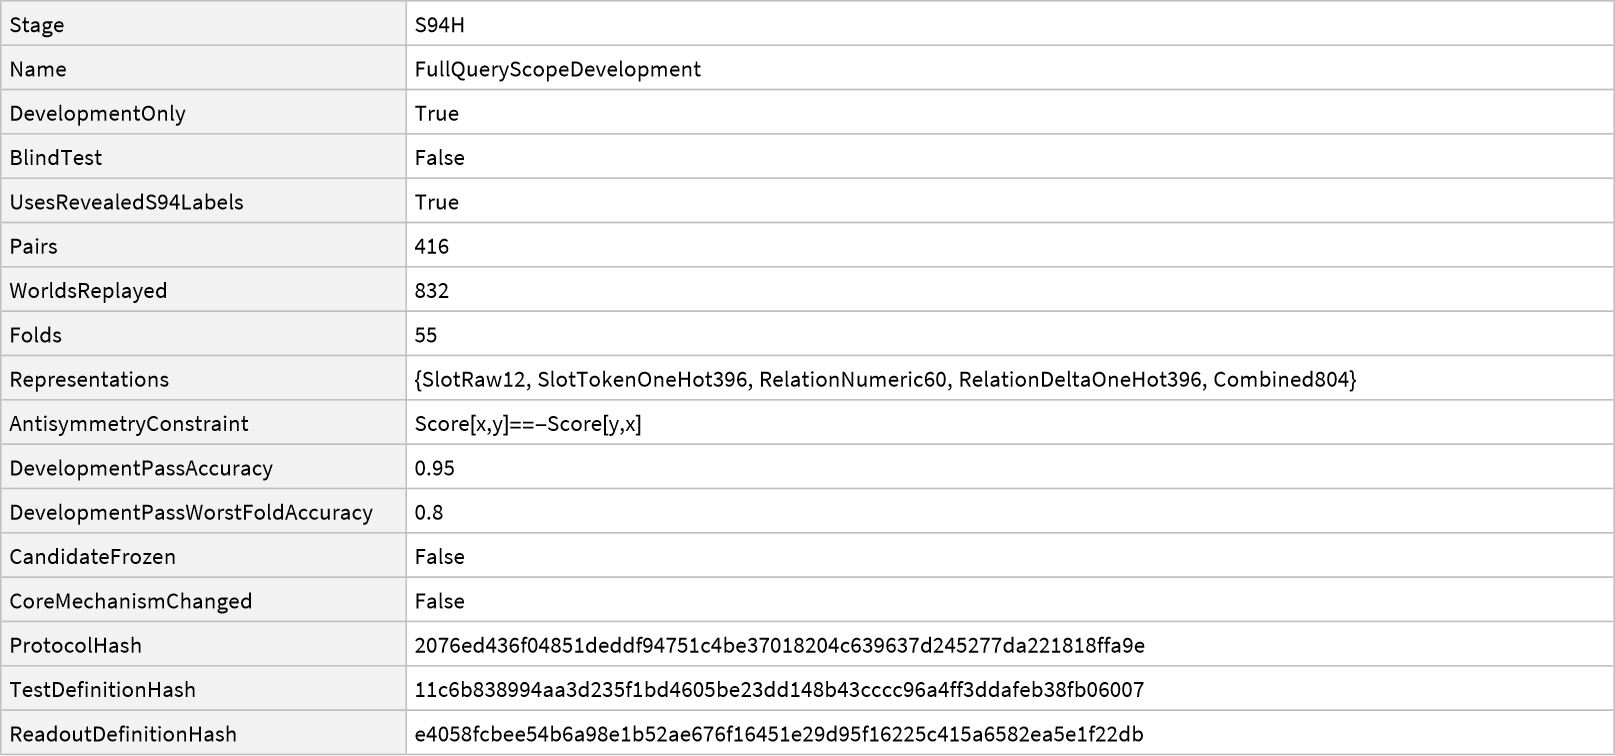

In [182]:
If[!TrueQ[preflightPassed94H],
Print["S94H blocked: preflight was not passed."];Abort[]];

If[!TrueQ[preflightPassed94H],
Print["S94H blocked: preflight was not passed."];Abort[]];

If[!TrueQ[preflightPassed94H],
Print["S94H blocked: preflight was not passed in this kernel."];Abort[]];

If[!TrueQ[preflightPassed94H],
Print["S94H blocked: preflight was not passed in this kernel."];Abort[]];

ClearAll[ContextAction94H,T94H,Case94H,ReferenceAction94H,NodeRole94H,
EncodePair94H,DiamondAfterDoubleAfterHierarchical94H,
HierarchicalAfterDiamondAfterDouble94H,DiamondAfterHierarchicalAfterDouble94H,
DoubleAfterHierarchicalAfterDiamond94H,TopologyTransform94H,
ExpectedContractions94H,RoleStatsTwelve94H,RoleMomentVector94H,
RoleInteractionVector94H,RoleEnhancedVector94H,RoleHistogramStats94H,
RoleHistogramVector94H,PrepareWorld94H,PrepareScenario94H,
RepresentationVector94H,FitAntisymmetricReadout94H,
ScoreAntisymmetricReadout94H,FoldMemberQ94H,EvaluateCandidate94H,
RepresentationAudit94H,AxisSummary94H,TestDefinitionBundle94H,
ReadoutDefinitionBundle94H];

contextPatterns94H={"AlternatingEven","AlternatingOdd","BlockHalf","TernarySparse"};
ContextAction94H[i_Integer,pattern_String,branchCount_Integer]:=Switch[pattern,
"AlternatingEven",If[EvenQ[i],"Continue","Stop"],
"AlternatingOdd",If[OddQ[i],"Continue","Stop"],
"BlockHalf",If[i<=Ceiling[branchCount/2],"Continue","Stop"],
"TernarySparse",If[Mod[i,3]===0,"Continue","Stop"],
_,"Undefined"];

T94H[depth_Integer,target_String,answer_Integer,seed_Integer,
branchCount_Integer,contextPattern_String]:=Module[
{bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,main,perm,anc,
branchAction,i},
bb=1000000000 seed;K=bb+1;
c=Table[bb+100+i,{i,branchCount}];v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[Table[{DirectedEdge[K,c[[i]]],DirectedEdge[c[[i]],v[[i]]]},{i,branchCount}],1];
Do[ib=bb+20000000 i;m=ib+1;safe=ib+2;u=ib+3;dummy=ib+4;
r1=ib+10;r2=ib+20;wrong=c[[1+Mod[i,branchCount]]];
main=Join[P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],{DirectedEdge[r1,m],DirectedEdge[r2,m]},
P59[q[[i]],safe,depth+1,ib+3000000]];
branchAction=If[i===answer,target,ContextAction94H[i,contextPattern,branchCount]];
perm=If[branchAction==="Continue",
{DirectedEdge[m,c[[i]]],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]},
{DirectedEdge[m,wrong],DirectedEdge[safe,c[[i]]],DirectedEdge[u,dummy]}];
anc=Join[A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]];
e=Join[e,main,perm,anc];AppendTo[f,m],{i,branchCount}];
{{Union[e],q,K,v,c,f},answer}];

Case94H[depth_Integer,answer_Integer,target_String,topologyIndex_Integer,
contextIndex_Integer,contextPattern_String]:=T94H[depth,target,answer,
94300000+10000 topologyIndex+1000 contextIndex+10 depth,13,contextPattern];

ReferenceAction94H[c_List]:=Module[{x=c[[1]],answer=c[[2]],branchCount,e,m,
safe,u,dummy,correct,wrong,continueEdges,stopEdges},
branchCount=Length[x[[6]]];e=x[[1]];m=x[[6,answer]];safe=m+1;u=m+2;
dummy=m+3;correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={DirectedEdge[m,correct],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]};
stopEdges={DirectedEdge[m,wrong],DirectedEdge[safe,correct],DirectedEdge[u,dummy]};
Which[And@@(MemberQ[e,#]&/@continueEdges),"Continue",
And@@(MemberQ[e,#]&/@stopEdges),"Stop",True,"Undefined"]];

NodeRole94H[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];branchCount=Length[x[[6]]];m=x[[6,answer]];
correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];dummy=m+3;
querySources={m,m+1,m+2};queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",True,"OtherReject"];
<|"Role"->role,"QueryBranchRelated"->MemberQ[queryBranch,originalNode]|>];

EncodePair94H[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[{<|"Grammar"->"S94HExpandedRoleAwareDevelopment",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled","StatePairs"->{pair}|>},
frozenCandidate86E["EncoderParams"],frozenCandidate86E["K"]];
First[encoded["Codes"]]];

DiamondAfterDoubleAfterHierarchical94H[c_List]:=
DiamondIn72[DoubleDiamondIn79[HierarchicalDiamondIn80[c]]];
HierarchicalAfterDiamondAfterDouble94H[c_List]:=
HierarchicalDiamondIn80[DiamondIn72[DoubleDiamondIn79[c]]];
DiamondAfterHierarchicalAfterDouble94H[c_List]:=
DiamondIn72[HierarchicalDiamondIn80[DoubleDiamondIn79[c]]];
DoubleAfterHierarchicalAfterDiamond94H[c_List]:=
DoubleDiamondIn79[HierarchicalDiamondIn80[DiamondIn72[c]]];
TopologyTransform94H[topology_String,c_List]:=Switch[topology,
"DiamondAfterDoubleAfterHierarchical",DiamondAfterDoubleAfterHierarchical94H[c],
"HierarchicalAfterDiamondAfterDouble",HierarchicalAfterDiamondAfterDouble94H[c],
"DiamondAfterHierarchicalAfterDouble",DiamondAfterHierarchicalAfterDouble94H[c],
"DoubleAfterHierarchicalAfterDiamond",DoubleAfterHierarchicalAfterDiamond94H[c],
_,$Failed];
ExpectedContractions94H[baseCase_List]:=6 DecisionIncomingEdgeCount79B[baseCase];

roleOrder94H={"QueriedDecision","QueriedMediatorSource",
"QueriedCorrectDestination","QueriedWrongDestination","QueriedDummyDestination"};
interactionRolePairs94H={{1,2},{1,3},{1,4},{3,4},{3,5},{4,5}};
RoleStatsTwelve94H[observations_List,role_String]:=Module[{selected,codes,a,b,d},
selected=Select[observations,SameQ[Lookup[#,"Role"],role]&];
codes=Lookup[selected,"Code",{}];
If[Length[codes]===0,Return[ConstantArray[0,12]]];
a=codes[[All,1]];b=codes[[All,2]];d=a-b;
{Length[codes],Total[a],Total[b],Total[a^2],Total[b^2],Total[a b],
Total[d],Total[Abs[d]],Total[d^2],Max[a],Max[b],Max[Abs[d]]}];
RoleMomentVector94H[observations_List]:=Flatten[
RoleStatsTwelve94H[observations,#]&/@roleOrder94H];
RoleInteractionVector94H[observations_List]:=Module[{stats},
stats=RoleStatsTwelve94H[observations,#]&/@roleOrder94H;
Flatten[(stats[[#[[1]]]] stats[[#[[2]]]])&/@interactionRolePairs94H]];
RoleEnhancedVector94H[observations_List]:=Join[
RoleMomentVector94H[observations],RoleInteractionVector94H[observations]];
RoleHistogramStats94H[observations_List,role_String]:=Module[
{selected,codes,a,b,d},
selected=Select[observations,SameQ[Lookup[#,"Role"],role]&];
codes=Lookup[selected,"Code",{}];
If[Length[codes]===0,Return[ConstantArray[0,99]]];
a=codes[[All,1]];b=codes[[All,2]];d=1+Mod[a-b,33];
Join[BinCounts[a,{0.5,33.5,1}],BinCounts[b,{0.5,33.5,1}],
BinCounts[d,{0.5,33.5,1}]]];
RoleHistogramVector94H[observations_List]:=Flatten[
RoleHistogramStats94H[observations,#]&/@roleOrder94H];

PrepareWorld94H[topology_String,topologyIndex_Integer,contextPattern_String,
contextIndex_Integer,depth_Integer,target_String,answer_Integer]:=Module[
{baseCase,topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,observations,
queryObservations,originalNode,pair,roleInfo,globalVector,roleMomentVector,
roleEnhancedVector,roleHistogramVector,nonQueryActions},
baseCase=Case94H[depth,answer,target,topologyIndex,contextIndex,contextPattern];
topologyCase=TopologyTransform94H[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions94H[baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[Length[trace["Rejects"]]===0,{},
DeleteDuplicates[trace["Rejects"][[All,2]]]];
observations=Map[Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole94H[originalNode,canonicalCase,answer];
<|"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair94H[pair]|>],packedNodes];
queryObservations=Select[observations,TrueQ[Lookup[#,"QueryBranchRelated",False]]&];
globalVector=TCCTWorldVectorS87D[<|"Observations"->observations|>];
roleMomentVector=RoleMomentVector94H[queryObservations];
roleEnhancedVector=RoleEnhancedVector94H[queryObservations];
roleHistogramVector=RoleHistogramVector94H[queryObservations];
nonQueryActions=ContextAction94H[#,contextPattern,13]&/@DeleteCases[Range[13],answer];
<|"Topology"->topology,"TopologyIndex"->topologyIndex,
"ContextPattern"->contextPattern,"ContextIndex"->contextIndex,
"Depth"->depth,"Answer"->answer,"Target"->target,
"ReferenceAction"->ReferenceAction94H[canonicalCase],
"NonQueryContinueBranches"->Count[nonQueryActions,"Continue"],
"NonQueryStopBranches"->Count[nonQueryActions,"Stop"],
"GlobalVector"->globalVector,"RoleMomentVector"->roleMomentVector,
"RoleEnhancedVector"->roleEnhancedVector,
"RoleHistogramVector"->roleHistogramVector,
"QueryObservationCount"->Length[queryObservations],
"QueryRoleCounts"->AssociationMap[
Count[Lookup[queryObservations,"Role"],#]&,roleOrder94H],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[canonicalization["Contractions"],expectedContractions],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],"TraceSeconds"->traceSeconds|>];

PrepareScenario94H[topology_String,topologyIndex_Integer,contextPattern_String,
contextIndex_Integer,depth_Integer]:=Module[{continueWorlds,stopWorlds,pairs,key},
key=StringRiffle[{topology,contextPattern,ToString[depth]},"|"];
continueWorlds=Table[PrepareWorld94H[topology,topologyIndex,contextPattern,
contextIndex,depth,"Continue",answer],{answer,13}];
stopWorlds=Table[PrepareWorld94H[topology,topologyIndex,contextPattern,
contextIndex,depth,"Stop",answer],{answer,13}];
pairs=MapThread[Function[{continue,stop},<|
"ScenarioKey"->key,"Topology"->topology,"TopologyIndex"->topologyIndex,
"ContextPattern"->contextPattern,"ContextIndex"->contextIndex,
"Depth"->depth,"Answer"->continue["Answer"],
"ContinueWorld"->continue,"StopWorld"->stop,
"GlobalDifference"->continue["GlobalVector"]-stop["GlobalVector"],
"RoleMomentDifference"->continue["RoleMomentVector"]-stop["RoleMomentVector"],
"RoleEnhancedDifference"->continue["RoleEnhancedVector"]-stop["RoleEnhancedVector"],
"RoleHistogramDifference"->continue["RoleHistogramVector"]-stop["RoleHistogramVector"],
"CombinedDifference"->Join[
continue["GlobalVector"]-stop["GlobalVector"],
continue["RoleEnhancedVector"]-stop["RoleEnhancedVector"],
continue["RoleHistogramVector"]-stop["RoleHistogramVector"]],
"ReferenceRelationCorrect"->And[
SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]]|>],{continueWorlds,stopWorlds}];
<|"ScenarioKey"->key,"Topology"->topology,"TopologyIndex"->topologyIndex,
"ContextPattern"->contextPattern,"ContextIndex"->contextIndex,
"Depth"->depth,"Pairs"->pairs,"ContinueWorlds"->continueWorlds,
"StopWorlds"->stopWorlds|>];

RepresentationVector94H[row_Association,representation_String]:=Switch[representation,
"Global27",row["GlobalDifference"],
"RoleMoment60",row["RoleMomentDifference"],
"RoleEnhanced132",row["RoleEnhancedDifference"],
"RoleHistogram495",row["RoleHistogramDifference"],
"Combined654",row["CombinedDifference"],_,$Failed];

FitAntisymmetricReadout94H[rows_List,representation_String,
family_String,lambda_?NumericQ]:=Module[
{differences,scale,z,mu,covariance,variance,weights},
differences=RepresentationVector94H[#,representation]&/@rows;
If[!MatrixQ[differences,NumericQ],Return[$Failed]];
scale=Sqrt[Mean[#^2]]&/@Transpose[differences];
scale=Map[If[!NumericQ[#]||Abs[N[#]]<10^-12,1.,N[#]]&,scale];
z=N[(#/scale)&/@differences];mu=Mean[z];
covariance=Transpose[z].z/Length[z]-Outer[Times,mu,mu];
variance=Diagonal[covariance];
weights=Switch[family,"Centroid",mu,
"DiagonalRidge",mu/(variance+lambda),
"FullRidge",Quiet@Check[
LinearSolve[covariance+lambda IdentityMatrix[Length[mu]],mu],$Failed],
_,$Failed];
If[!VectorQ[weights,NumericQ],Return[$Failed]];
<|"Representation"->representation,"Family"->family,
"Lambda"->lambda,"Scale"->scale,"Weights"->weights|>];
ScoreAntisymmetricReadout94H[model_Association,difference_List]:=
N[Total[model["Weights"] (difference/model["Scale"])]];

FoldMemberQ94H[row_Association,fold_Association]:=Switch[fold["Axis"],
"Topology",SameQ[row["Topology"],fold["Heldout"]],
"ContextPattern",SameQ[row["ContextPattern"],fold["Heldout"]],
"Depth",SameQ[row["Depth"],fold["Heldout"]],
"Answer",SameQ[row["Answer"],fold["Heldout"]],
"Scenario",SameQ[row["ScenarioKey"],fold["Heldout"]],_,False];
EvaluateCandidate94H[rows_List,folds_List,spec_Association]:=Module[
{foldRows},foldRows=Map[Function[fold,Module[{train,test,model,scores},
test=Select[rows,TrueQ[FoldMemberQ94H[#,fold]]&];
train=Select[rows,!TrueQ[FoldMemberQ94H[#,fold]]&];
model=FitAntisymmetricReadout94H[train,spec["Representation"],
spec["Family"],spec["Lambda"]];
scores=If[AssociationQ[model],ScoreAntisymmetricReadout94H[model,
RepresentationVector94H[#,spec["Representation"]]]&/@test,{}];
<|"Axis"->fold["Axis"],"Heldout"->ToString[fold["Heldout"]],
"Cases"->Length[test],"Correct"->Count[scores,x_/;x>0],
"ZeroScores"->Count[scores,x_/;Abs[x]<10^-12],
"Accuracy"->If[Length[test]>0,N[Count[scores,x_/;x>0]/Length[test]],0.],
"MinimumMargin"->If[Length[scores]>0,Min[scores],-Infinity]|>]],folds];
Join[spec,<|"Folds"->Length[foldRows],"Cases"->Total@Lookup[foldRows,"Cases"],
"Correct"->Total@Lookup[foldRows,"Correct"],
"Accuracy"->N[Total@Lookup[foldRows,"Correct"]/Total@Lookup[foldRows,"Cases"]],
"WorstFoldAccuracy"->Min@Lookup[foldRows,"Accuracy"],
"ZeroScores"->Total@Lookup[foldRows,"ZeroScores"],
"MinimumMargin"->Min@Lookup[foldRows,"MinimumMargin"],
"FoldResults"->foldRows|>]];

RepresentationAudit94H[rows_List,representation_String]:=Module[
{vectors,unique,oppositeConflicts},
vectors=RepresentationVector94H[#,representation]&/@rows;
unique=DeleteDuplicates[vectors];oppositeConflicts=Intersection[unique,-unique];
<|"Representation"->representation,"Dimension"->Length[First[vectors]],
"ZeroVectors"->Count[vectors,ConstantArray[0,Length[First[vectors]]]],
"UniqueVectors"->Length[unique],
"AntisymmetricAliasConflicts"->Length[oppositeConflicts]|>];
AxisSummary94H[foldRows_List]:=Map[Function[axis,Module[{rows},
rows=Select[foldRows,SameQ[Lookup[#,"Axis"],axis]&];
<|"Axis"->axis,"Folds"->Length[rows],"Cases"->Total@Lookup[rows,"Cases"],
"Correct"->Total@Lookup[rows,"Correct"],
"Accuracy"->N[Total@Lookup[rows,"Correct"]/Total@Lookup[rows,"Cases"]],
"WorstFoldAccuracy"->Min@Lookup[rows,"Accuracy"]|>]],
{"Topology","ContextPattern","Depth","Answer","Scenario"}];

TestDefinitionBundle94H[]:={DownValues[ContextAction94H],DownValues[T94H],
DownValues[Case94H],DownValues[ReferenceAction94H],DownValues[NodeRole94H],
DownValues[EncodePair94H],DownValues[DiamondAfterDoubleAfterHierarchical94H],
DownValues[HierarchicalAfterDiamondAfterDouble94H],
DownValues[DiamondAfterHierarchicalAfterDouble94H],
DownValues[DoubleAfterHierarchicalAfterDiamond94H],DownValues[TopologyTransform94H],
DownValues[ExpectedContractions94H],DownValues[RoleStatsTwelve94H],
DownValues[RoleMomentVector94H],DownValues[RoleInteractionVector94H],
DownValues[RoleEnhancedVector94H],DownValues[RoleHistogramStats94H],
DownValues[RoleHistogramVector94H],DownValues[PrepareWorld94H],
DownValues[PrepareScenario94H]};
ReadoutDefinitionBundle94H[]:={DownValues[RepresentationVector94H],
DownValues[FitAntisymmetricReadout94H],DownValues[ScoreAntisymmetricReadout94H],
DownValues[FoldMemberQ94H],DownValues[EvaluateCandidate94H],
DownValues[RepresentationAudit94H],DownValues[AxisSummary94H]};

ClearAll[TraceWorldStages94H,PairStageAudit94H,StageSignature94H,
DifferentQ94H,FirstLossDiagnosis94H,AuditDefinitionBundle94H];
StageSignature94H[x_]:=Hash[x,"SHA256","HexString"];
DifferentQ94H[a_,b_]:=!SameQ[a,b];

TraceWorldStages94H[row_Association,target_String]:=Module[
{baseCase,topologyCase,canonicalization,canonicalCase,traceSeconds,trace,
levels,pack,vertexList,allPackedNodes,allOriginalNodes,rawPairs,allRawMap,
allCodeMap,queryPackedNodes,queryOriginalNodes,rejectPackedSequence,
rejectOriginalSequence,queryRejectPackedSequence,preDedupPackedSequence,
postDedupPackedNodes,makeObservation,allRejectObservations,
preDedupQueryObservations,postDedupQueryObservations,globalVector,
roleMomentVector,roleEnhancedVector,roleHistogramVector},
baseCase=Case94H[row["Depth"],row["Answer"],target,row["TopologyIndex"],
row["ContextIndex"],row["ContextPattern"]];
topologyCase=TopologyTransform94H[row["Topology"],baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];pack=Pack60[canonicalCase];
vertexList=pack[[12]];allPackedNodes=Range[Length[vertexList]];
allOriginalNodes=vertexList;
rawPairs=({Lookup[levels[[3]],#],Lookup[levels[[4]],#]}&)/@allPackedNodes;
allRawMap=AssociationThread[allOriginalNodes,rawPairs];
allCodeMap=AssociationThread[allOriginalNodes,EncodePair94H/@rawPairs];
queryPackedNodes=Select[allPackedNodes,TrueQ[
NodeRole94H[vertexList[[#]],canonicalCase,row["Answer"]]["QueryBranchRelated"]]&];
queryOriginalNodes=vertexList[[queryPackedNodes]];
rejectPackedSequence=If[Length[trace["Rejects"]]===0,{},trace["Rejects"][[All,2]]];
rejectOriginalSequence=If[Length[rejectPackedSequence]===0,{},
vertexList[[rejectPackedSequence]]];
queryRejectPackedSequence=Select[rejectPackedSequence,
MemberQ[queryPackedNodes,#]&];
preDedupPackedSequence=queryRejectPackedSequence;
postDedupPackedNodes=DeleteDuplicates[queryRejectPackedSequence];
makeObservation=Function[packedNode,Module[{originalNode,roleInfo,pair},
originalNode=vertexList[[packedNode]];
roleInfo=NodeRole94H[originalNode,canonicalCase,row["Answer"]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
<|"OriginalNode"->originalNode,"Role"->roleInfo["Role"],
"RawStateHash"->StageSignature94H[pair],"Code"->EncodePair94H[pair]|>]];
allRejectObservations=makeObservation/@DeleteDuplicates[rejectPackedSequence];
preDedupQueryObservations=makeObservation/@preDedupPackedSequence;
postDedupQueryObservations=makeObservation/@postDedupPackedNodes;
globalVector=TCCTWorldVectorS87D[<|"Observations"->allRejectObservations|>];
roleMomentVector=RoleMomentVector94H[postDedupQueryObservations];
roleEnhancedVector=RoleEnhancedVector94H[postDedupQueryObservations];
roleHistogramVector=RoleHistogramVector94H[postDedupQueryObservations];
<|"Target"->target,"ReferenceAction"->ReferenceAction94H[canonicalCase],
"CanonicalEdges"->canonicalCase[[1,1]],
"AllRawMap"->allRawMap,"AllCodeMap"->allCodeMap,
"QueryRawMap"->KeyTake[allRawMap,queryOriginalNodes],
"QueryCodeMap"->KeyTake[allCodeMap,queryOriginalNodes],
"RejectOriginalSequence"->rejectOriginalSequence,
"PreDedupQueryObservations"->preDedupQueryObservations,
"PostDedupQueryObservations"->postDedupQueryObservations,
"GlobalVector"->globalVector,"RoleMomentVector"->roleMomentVector,
"RoleEnhancedVector"->roleEnhancedVector,
"RoleHistogramVector"->roleHistogramVector,
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"ContractionCountCorrect"->SameQ[canonicalization["Contractions"],
ExpectedContractions94H[baseCase]],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],"TraceSeconds"->traceSeconds|>];

FirstLossDiagnosis94H[flags_Association]:=Which[
!TrueQ[flags["CanonicalGraphDistinguishable"]],"INVALID_IDENTICAL_COUNTERFACTUAL_GRAPHS",
!TrueQ[flags["AllRawStatesDistinguishable"]],"RAW_RADIUS_STATE_COLLAPSE",
!TrueQ[flags["AllEncodedTokensDistinguishable"]],"FROZEN_ENCODER_COMPRESSION_LOSS",
!TrueQ[flags["RejectTraceDistinguishable"]],"CORE_REJECT_TRACE_SELECTION_LOSS",
!TrueQ[flags["PreDedupQueryObservationsDistinguishable"]],"QUERY_OBSERVATION_SCOPE_LOSS",
!TrueQ[flags["PostDedupQueryObservationsDistinguishable"]],"DEDUPLICATION_INFORMATION_LOSS",
True,"OUTER_AGGREGATION_LOSS"];

PairStageAudit94H[row_Association]:=Module[{continue,stop,flags,diagnosis},
continue=TraceWorldStages94H[row,"Continue"];
stop=TraceWorldStages94H[row,"Stop"];
flags=<|
"CanonicalGraphDistinguishable"->DifferentQ94H[continue["CanonicalEdges"],stop["CanonicalEdges"]],
"AllRawStatesDistinguishable"->DifferentQ94H[continue["AllRawMap"],stop["AllRawMap"]],
"QueryRawStatesDistinguishable"->DifferentQ94H[continue["QueryRawMap"],stop["QueryRawMap"]],
"AllEncodedTokensDistinguishable"->DifferentQ94H[continue["AllCodeMap"],stop["AllCodeMap"]],
"QueryEncodedTokensDistinguishable"->DifferentQ94H[continue["QueryCodeMap"],stop["QueryCodeMap"]],
"RejectTraceDistinguishable"->DifferentQ94H[continue["RejectOriginalSequence"],stop["RejectOriginalSequence"]],
"PreDedupQueryObservationsDistinguishable"->DifferentQ94H[
continue["PreDedupQueryObservations"],stop["PreDedupQueryObservations"]],
"PostDedupQueryObservationsDistinguishable"->DifferentQ94H[
continue["PostDedupQueryObservations"],stop["PostDedupQueryObservations"]],
"GlobalAggregateDistinguishable"->DifferentQ94H[continue["GlobalVector"],stop["GlobalVector"]],
"RoleMomentAggregateDistinguishable"->DifferentQ94H[
continue["RoleMomentVector"],stop["RoleMomentVector"]],
"RoleEnhancedAggregateDistinguishable"->DifferentQ94H[
continue["RoleEnhancedVector"],stop["RoleEnhancedVector"]],
"RoleHistogramAggregateDistinguishable"->DifferentQ94H[
continue["RoleHistogramVector"],stop["RoleHistogramVector"]]|>;
diagnosis=FirstLossDiagnosis94H[flags];
Join[KeyTake[row,{"ScenarioKey","Topology","TopologyIndex","ContextPattern",
"ContextIndex","Depth","Answer"}],flags,<|
"Diagnosis"->diagnosis,
"ReferenceActionsCorrect"->And[SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]],
"RegeneratedGlobalDifferenceMatches"->SameQ[
continue["GlobalVector"]-stop["GlobalVector"],row["GlobalDifference"]],
"RegeneratedRoleMomentDifferenceMatches"->SameQ[
continue["RoleMomentVector"]-stop["RoleMomentVector"],row["RoleMomentDifference"]],
"RegeneratedRoleEnhancedDifferenceMatches"->SameQ[
continue["RoleEnhancedVector"]-stop["RoleEnhancedVector"],row["RoleEnhancedDifference"]],
"RegeneratedRoleHistogramDifferenceMatches"->SameQ[
continue["RoleHistogramVector"]-stop["RoleHistogramVector"],row["RoleHistogramDifference"]],
"CanonicalizationValid"->And[continue["CanonicalCaseExactlyBase"],
stop["CanonicalCaseExactlyBase"],continue["ContractionCountCorrect"],
stop["ContractionCountCorrect"],continue["ProtectedNodesPreserved"],
stop["ProtectedNodesPreserved"]],
"TracesValid"->And[continue["TerminatedNaturally"],stop["TerminatedNaturally"],
!continue["HitSafetyCap"],!stop["HitSafetyCap"]],
"TraceSeconds"->continue["TraceSeconds"]+stop["TraceSeconds"]|>]];

AuditDefinitionBundle94H[]:={DownValues[TraceWorldStages94H],
DownValues[PairStageAudit94H],DownValues[StageSignature94H],
DownValues[DifferentQ94H],DownValues[FirstLossDiagnosis94H]};

ClearAll[SemanticSlot94H,SemanticAlignedMap94H,ChannelWorld94H,
ChannelPairAudit94H,ChannelDiagnosis94H,ChannelDefinitionBundle94H];
semanticSlotOrder94H={"DecisionSource","SafeSource","AlternativeSource",
"CorrectDestination","WrongDestination","DummyDestination"};
SemanticSlot94H[node_,case_List,answer_Integer]:=Module[
{x,n,m,correct,wrong,dummy},x=case[[1]];n=Length[x[[6]]];m=x[[6,answer]];
correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,n]]];dummy=m+3;
Which[SameQ[node,m],"DecisionSource",SameQ[node,m+1],"SafeSource",
SameQ[node,m+2],"AlternativeSource",SameQ[node,correct],"CorrectDestination",
SameQ[node,wrong],"WrongDestination",SameQ[node,dummy],"DummyDestination",
True,"OutsideQuery"]];
SemanticAlignedMap94H[nodeMap_Association,case_List,answer_Integer]:=Module[
{rows},rows=KeyValueMap[<|"Slot"->SemanticSlot94H[#1,case,answer],
"Value"->#2|>&,nodeMap];AssociationMap[Function[slot,
Sort[Lookup[Select[rows,SameQ[Lookup[#,"Slot"],slot]&],"Value",{}],
OrderedQ[{ToString[#1,InputForm],ToString[#2,InputForm]}]&]],semanticSlotOrder94H]];

ChannelWorld94H[row_Association,target_String]:=Module[
{traceWorld,baseCase,rejectedNodes,rejectedRawNodeMap,rejectedCodeNodeMap},
traceWorld=TraceWorldStages94H[row,target];
baseCase=Case94H[row["Depth"],row["Answer"],target,row["TopologyIndex"],
row["ContextIndex"],row["ContextPattern"]];
rejectedNodes=DeleteDuplicates[Lookup[
traceWorld["PostDedupQueryObservations"],"OriginalNode",{}]];
rejectedRawNodeMap=KeyTake[traceWorld["QueryRawMap"],rejectedNodes];
rejectedCodeNodeMap=KeyTake[traceWorld["QueryCodeMap"],rejectedNodes];
<|"ReferenceAction"->traceWorld["ReferenceAction"],
"FullQueryRaw"->SemanticAlignedMap94H[traceWorld["QueryRawMap"],baseCase,row["Answer"]],
"FullQueryTokens"->SemanticAlignedMap94H[traceWorld["QueryCodeMap"],baseCase,row["Answer"]],
"RejectedRaw"->SemanticAlignedMap94H[rejectedRawNodeMap,baseCase,row["Answer"]],
"RejectedTokens"->SemanticAlignedMap94H[rejectedCodeNodeMap,baseCase,row["Answer"]],
"RejectedNodeCount"->Length[rejectedNodes],
"TerminatedNaturally"->traceWorld["TerminatedNaturally"],
"HitSafetyCap"->traceWorld["HitSafetyCap"],"TraceSeconds"->traceWorld["TraceSeconds"]|>];

ChannelDiagnosis94H[fullToken_,rejectedRaw_,rejectedToken_]:=Which[
TrueQ[fullToken]&&!TrueQ[rejectedToken],"OBSERVATION_SCOPE_LOSS_TOKEN_SURVIVES_OUTSIDE_REJECTS",
TrueQ[rejectedRaw]&&!TrueQ[rejectedToken],"FROZEN_ENCODER_COMPRESSION_ON_REJECTED_NODES",
TrueQ[fullToken]&&TrueQ[rejectedToken],"DOWNSTREAM_AGGREGATION_ONLY",
!TrueQ[fullToken]&&TrueQ[rejectedRaw],"FROZEN_ENCODER_COMPRESSION_ACROSS_QUERY_SCOPE",
True,"RAW_STATE_OR_ALIGNMENT_LIMITATION"];
ChannelPairAudit94H[row_Association]:=Module[{continue,stop,fullRaw,fullToken,
rejectedRaw,rejectedToken,diagnosis,changedFullRaw,changedFullToken,
changedRejectedRaw,changedRejectedToken},
continue=ChannelWorld94H[row,"Continue"];stop=ChannelWorld94H[row,"Stop"];
fullRaw=!SameQ[continue["FullQueryRaw"],stop["FullQueryRaw"]];
fullToken=!SameQ[continue["FullQueryTokens"],stop["FullQueryTokens"]];
rejectedRaw=!SameQ[continue["RejectedRaw"],stop["RejectedRaw"]];
rejectedToken=!SameQ[continue["RejectedTokens"],stop["RejectedTokens"]];
changedFullRaw=Select[semanticSlotOrder94H,!SameQ[
continue["FullQueryRaw"][#],stop["FullQueryRaw"][#]]&];
changedFullToken=Select[semanticSlotOrder94H,!SameQ[
continue["FullQueryTokens"][#],stop["FullQueryTokens"][#]]&];
changedRejectedRaw=Select[semanticSlotOrder94H,!SameQ[
continue["RejectedRaw"][#],stop["RejectedRaw"][#]]&];
changedRejectedToken=Select[semanticSlotOrder94H,!SameQ[
continue["RejectedTokens"][#],stop["RejectedTokens"][#]]&];
diagnosis=ChannelDiagnosis94H[fullToken,rejectedRaw,rejectedToken];
Join[KeyTake[row,{"ScenarioKey","Topology","TopologyIndex","ContextPattern",
"ContextIndex","Depth","Answer"}],<|
"FullQueryRawDistinguishable"->fullRaw,
"FullQueryTokenDistinguishable"->fullToken,
"RejectedRawDistinguishable"->rejectedRaw,
"RejectedTokenDistinguishable"->rejectedToken,
"ChangedFullQueryRawSlots"->changedFullRaw,
"ChangedFullQueryTokenSlots"->changedFullToken,
"ChangedRejectedRawSlots"->changedRejectedRaw,
"ChangedRejectedTokenSlots"->changedRejectedToken,
"ContinueRejectedNodeCount"->continue["RejectedNodeCount"],
"StopRejectedNodeCount"->stop["RejectedNodeCount"],"Diagnosis"->diagnosis,
"ReferenceActionsCorrect"->And[SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]],
"TracesValid"->And[continue["TerminatedNaturally"],stop["TerminatedNaturally"],
!continue["HitSafetyCap"],!stop["HitSafetyCap"]],
"TraceSeconds"->continue["TraceSeconds"]+stop["TraceSeconds"]|>]];
ChannelDefinitionBundle94H[]:={DownValues[SemanticSlot94H],
DownValues[SemanticAlignedMap94H],DownValues[ChannelWorld94H],
DownValues[ChannelPairAudit94H],DownValues[ChannelDiagnosis94H]};

ClearAll[SlotCode94H,OneHot94H,SlotRawVector94H,SlotTokenOneHot94H,
RelationNumericVector94H,RelationDeltaOneHot94H,FullQueryFeatureVector94H,
PrepareFullQueryPair94H,FoldMember94H,FitReadout94H,ScoreReadout94H,
EvaluateCandidate94H,RepresentationAudit94H,AxisSummary94H,
ReadoutDefinitionBundle94H];
relationPairs94H={{"DecisionSource","CorrectDestination"},
{"DecisionSource","WrongDestination"},{"SafeSource","CorrectDestination"},
{"SafeSource","DummyDestination"},{"AlternativeSource","WrongDestination"},
{"AlternativeSource","DummyDestination"}};
SlotCode94H[slotMap_Association,slot_String]:=Module[{values},
values=Lookup[slotMap,slot,{}];If[Length[values]===0,{0,0},First[values]]];
OneHot94H[value_Integer,size_Integer]:=If[1<=value<=size,
Normal@SparseArray[{value->1},size],ConstantArray[0,size]];
SlotRawVector94H[slotMap_Association]:=Flatten[
SlotCode94H[slotMap,#]&/@semanticSlotOrder94H];
SlotTokenOneHot94H[slotMap_Association]:=Flatten[Map[Function[slot,
Flatten[OneHot94H[#,33]&/@SlotCode94H[slotMap,slot]]],semanticSlotOrder94H]];
RelationNumericVector94H[slotMap_Association]:=Flatten[Map[Function[pair,
Module[{source,destination,delta},source=SlotCode94H[slotMap,pair[[1]]];
destination=SlotCode94H[slotMap,pair[[2]]];delta=source-destination;
Join[source,destination,delta,source destination,
{Total[source destination],Total[Abs[delta]]}]]],relationPairs94H]];
RelationDeltaOneHot94H[slotMap_Association]:=Flatten[Map[Function[pair,
Module[{source,destination,delta},source=SlotCode94H[slotMap,pair[[1]]];
destination=SlotCode94H[slotMap,pair[[2]]];delta=1+Mod[source-destination,33];
Flatten[OneHot94H[#,33]&/@delta]]],relationPairs94H]];
FullQueryFeatureVector94H[slotMap_Association,representation_String]:=Switch[
representation,"SlotRaw12",SlotRawVector94H[slotMap],
"SlotTokenOneHot396",SlotTokenOneHot94H[slotMap],
"RelationNumeric60",RelationNumericVector94H[slotMap],
"RelationDeltaOneHot396",RelationDeltaOneHot94H[slotMap],
"Combined804",Join[SlotRawVector94H[slotMap],SlotTokenOneHot94H[slotMap],
RelationDeltaOneHot94H[slotMap]],_,$Failed];

PrepareFullQueryPair94H[row_Association]:=Module[{continue,stop,reps,differences},
continue=ChannelWorld94H[row,"Continue"];stop=ChannelWorld94H[row,"Stop"];
reps={"SlotRaw12","SlotTokenOneHot396","RelationNumeric60",
"RelationDeltaOneHot396","Combined804"};
differences=AssociationMap[FullQueryFeatureVector94H[continue["FullQueryTokens"],#]-
FullQueryFeatureVector94H[stop["FullQueryTokens"],#]&,reps];
Join[KeyTake[row,{"ScenarioKey","Topology","TopologyIndex","ContextPattern",
"ContextIndex","Depth","Answer"}],<|"Differences"->differences,
"FullQueryTokensDistinguishable"->!SameQ[continue["FullQueryTokens"],
stop["FullQueryTokens"]],"ReferenceActionsCorrect"->And[
SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]],"TracesValid"->And[
continue["TerminatedNaturally"],stop["TerminatedNaturally"],
!continue["HitSafetyCap"],!stop["HitSafetyCap"]],
"TraceSeconds"->continue["TraceSeconds"]+stop["TraceSeconds"]|>]];
FoldMember94H[row_Association,fold_Association]:=Switch[fold["Axis"],
"Topology",SameQ[row["Topology"],fold["Heldout"]],
"ContextPattern",SameQ[row["ContextPattern"],fold["Heldout"]],
"Depth",SameQ[row["Depth"],fold["Heldout"]],
"Answer",SameQ[row["Answer"],fold["Heldout"]],
"Scenario",SameQ[row["ScenarioKey"],fold["Heldout"]],_,False];
FitReadout94H[rows_List,representation_String,family_String,lambda_?NumericQ]:=Module[
{x,scale,z,mu,variance,covariance,weights},x=N[
Lookup[Lookup[#,"Differences"],representation]&/@rows];
If[!MatrixQ[x,NumericQ],Return[$Failed]];
scale=Sqrt[Mean[#^2]]&/@Transpose[x];
scale=Map[If[!NumericQ[#]||Abs[#]<10^-12,1.,#]&,scale];z=(#/scale)&/@x;mu=Mean[z];
weights=Switch[family,"Centroid",mu,
"DiagonalRidge",variance=Mean[(#-mu)^2&/@z];mu/(variance+lambda),
"FullRidge",covariance=Transpose[z].z/Length[z]-Outer[Times,mu,mu];
Quiet@Check[LinearSolve[covariance+lambda IdentityMatrix[Length[mu]],mu],$Failed],
_,$Failed];If[!VectorQ[weights,NumericQ],Return[$Failed]];
<|"Representation"->representation,"Family"->family,"Lambda"->lambda,
"Scale"->scale,"Weights"->weights|>];
ScoreReadout94H[model_Association,difference_List]:=
N[Total[model["Weights"] (difference/model["Scale"])]];
EvaluateCandidate94H[rows_List,folds_List,spec_Association]:=Module[{foldRows},
foldRows=Map[Function[fold,Module[{train,test,model,scores},
test=Select[rows,TrueQ[FoldMember94H[#,fold]]&];
train=Select[rows,!TrueQ[FoldMember94H[#,fold]]&];
model=FitReadout94H[train,spec["Representation"],spec["Family"],spec["Lambda"]];
scores=If[AssociationQ[model],ScoreReadout94H[model,
Lookup[Lookup[#,"Differences"],spec["Representation"]]]&/@test,{}];
<|"Axis"->fold["Axis"],"Heldout"->ToString[fold["Heldout"]],
"Cases"->Length[test],"Correct"->Count[scores,x_/;x>0],
"ZeroScores"->Count[scores,x_/;Abs[x]<10^-12],
"Accuracy"->N[Count[scores,x_/;x>0]/Length[test]],
"MinimumMargin"->Min[scores]|>]],folds];
Join[spec,<|"Folds"->Length[foldRows],"Cases"->Total@Lookup[foldRows,"Cases"],
"Correct"->Total@Lookup[foldRows,"Correct"],
"Accuracy"->N[Total@Lookup[foldRows,"Correct"]/Total@Lookup[foldRows,"Cases"]],
"WorstFoldAccuracy"->Min@Lookup[foldRows,"Accuracy"],
"ZeroScores"->Total@Lookup[foldRows,"ZeroScores"],
"MinimumMargin"->Min@Lookup[foldRows,"MinimumMargin"],
"FoldResults"->foldRows|>]];
RepresentationAudit94H[rows_List,representation_String]:=Module[{vectors,unique},
vectors=Lookup[Lookup[#,"Differences"],representation]&/@rows;
unique=DeleteDuplicates[vectors];
<|"Representation"->representation,"Dimension"->Length[First[vectors]],
"ZeroVectors"->Count[vectors,ConstantArray[0,Length[First[vectors]]]],
"UniqueVectors"->Length[unique],
"AntisymmetricAliasConflicts"->Length[Intersection[unique,-unique]]|>];
AxisSummary94H[foldRows_List]:=Map[Function[axis,Module[{r},
r=Select[foldRows,SameQ[Lookup[#,"Axis"],axis]&];
<|"Axis"->axis,"Folds"->Length[r],"Cases"->Total@Lookup[r,"Cases"],
"Accuracy"->N[Total@Lookup[r,"Correct"]/Total@Lookup[r,"Cases"]],
"WorstFoldAccuracy"->Min@Lookup[r,"Accuracy"]|>]],
{"Topology","ContextPattern","Depth","Answer","Scenario"}];
ReadoutDefinitionBundle94H[]:={DownValues[SlotCode94H],DownValues[OneHot94H],
DownValues[SlotRawVector94H],DownValues[SlotTokenOneHot94H],
DownValues[RelationNumericVector94H],DownValues[RelationDeltaOneHot94H],
DownValues[FullQueryFeatureVector94H],DownValues[PrepareFullQueryPair94H],
DownValues[FoldMember94H],DownValues[FitReadout94H],DownValues[ScoreReadout94H],
DownValues[EvaluateCandidate94H],DownValues[RepresentationAudit94H],
DownValues[AxisSummary94H]};
testDefinitionHashBefore94H=Hash[TestDefinitionBundle94H[],"SHA256","HexString"];
traceDefinitionHashBefore94H=Hash[AuditDefinitionBundle94H[],"SHA256","HexString"];
channelDefinitionHashBefore94H=Hash[ChannelDefinitionBundle94H[],"SHA256","HexString"];
readoutDefinitionHashBefore94H=Hash[ReadoutDefinitionBundle94H[],"SHA256","HexString"];
protocol94H=<|"Stage"->"S94H","Name"->"FullQueryScopeDevelopment",
"DevelopmentOnly"->True,"BlindTest"->False,"UsesRevealedS94Labels"->True,
"Pairs"->416,"WorldsReplayed"->832,"Folds"->55,
"Representations"->{"SlotRaw12","SlotTokenOneHot396","RelationNumeric60",
"RelationDeltaOneHot396","Combined804"},
"AntisymmetryConstraint"->"Score[x,y]==-Score[y,x]",
"DevelopmentPassAccuracy"->0.95,"DevelopmentPassWorstFoldAccuracy"->0.8,
"CandidateFrozen"->False,"CoreMechanismChanged"->False|>;
protocolHash94H=Hash[Normal[protocol94H],"SHA256","HexString"];
Dataset[{Join[protocol94H,<|"ProtocolHash"->protocolHash94H,
"TestDefinitionHash"->testDefinitionHashBefore94H,
"ReadoutDefinitionHash"->readoutDefinitionHashBefore94H|>]}]


Dataset[{<|Stage -> S94H, CandidateFrozenBeforeConfirmation -> True, 
 
>     Representation -> SlotRaw12, Family -> Centroid, 
 
>     CandidateHash -> 5ec0e4eb89e9bb447a1e103537c7b4a82eab0c807023cd5862048372efdb418b, 
 
>     CandidateFileHash -> 
 
>      8cbf7184200c6a04072f9b375af3137534dc3764bff7a32bf57db4a320187e1e, 
 
>     CandidateRecoveredAfterHarnessError -> True, CandidateReexported -> False, 
 
>     ConfirmationWorldsGeneratedYet -> False, CandidateSearchPerformed -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, CandidateFrozenBeforeConfirmation, 
 
>      Representation, Family, CandidateHash, CandidateFileHash, 
 
>      CandidateRecoveredAfterHarnessError, CandidateReexported, 
 
>      ConfirmationWorldsGeneratedYet, CandidateSearchPerformed}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
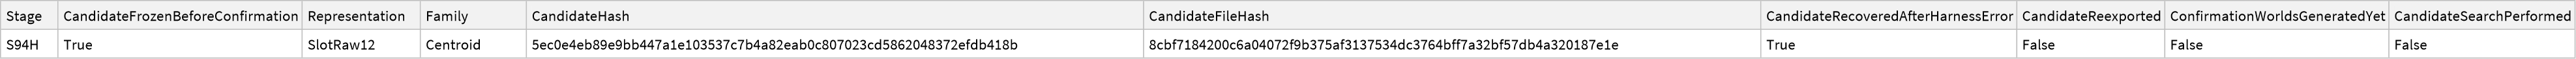

In [262]:
If[!TrueQ[preflightPassed94H],
Print["S94H blocked before candidate freeze: preflight is not True."];Abort[]];
If[Or[ValueQ[confirmationScenarios94H],ValueQ[confirmationPairs94H],
ValueQ[confirmationWorldsGenerated94H]],
Print["S94H aborted: confirmation data existed before candidate freeze."];Abort[]];
developmentRows94H=s94gArtifact94H["Rows"];
selectionRule94H=<|"Representation"->"SlotRaw12","Family"->"Centroid",
"Lambda"->1.,"Reason"->"Simplest representation among tied perfect candidates"|>;
x94H=N[Lookup[Lookup[#,"Differences"],"SlotRaw12"]&/@developmentRows94H];
scale94H=Sqrt[Mean[#^2]]&/@Transpose[x94H];
scale94H=Map[If[!NumericQ[#]||Abs[#]<10^-12,1.,#]&,scale94H];
weights94H=Mean[(#/scale94H)&/@x94H];
developmentScores94H=N[Total[weights94H (#/scale94H)]]&/@x94H;
candidatePayload94H=<|"Stage"->"S94H","Name"->"FrozenFullQueryReadout",
"Representation"->"SlotRaw12","Family"->"Centroid","Lambda"->1.,
"Scale"->scale94H,"Weights"->weights94H,"SelectionRule"->selectionRule94H,
"TrainingPairs"->Length[developmentRows94H],
"TrainingCorrect"->Count[developmentScores94H,s_/;s>0],
"TrainingMinimumMargin"->Min[developmentScores94H],
"SourceS94GResultHash"->expectedS94GResultHash94H,
"SourceS94GArtifactFileHash"->expectedS94GArtifactFileHash94H,
"FrozenBeforeConfirmationDataGeneration"->True|>;
candidateObjectHash94H=Hash[Normal[candidatePayload94H],"SHA256","HexString"];
frozenCandidate94H=Append[candidatePayload94H,"CandidateHash"->candidateObjectHash94H];
candidateFileHash94H=FileSHA256Hex94H[frozenCandidatePath94H];
candidateReloaded94H=Quiet@Check[Import[frozenCandidatePath94H,"WXF"],$Failed];
candidateReloadMatched94H=AssociationQ[candidateReloaded94H]&&
SameQ[candidateReloaded94H["CandidateHash"],candidateObjectHash94H]&&
SameQ[Hash[Normal@KeyDrop[candidateReloaded94H,{"CandidateHash"}],
"SHA256","HexString"],candidateObjectHash94H];
candidateRecoveredAfterHarnessError94H=And[
SameQ[candidateObjectHash94H,expectedFrozenCandidateObjectHash94H],
SameQ[candidateFileHash94H,expectedFrozenCandidateFileHash94H],
candidateReloadMatched94H];
candidateFrozenBeforeConfirmation94H=And[candidateRecoveredAfterHarnessError94H,
candidateReloadMatched94H,SameQ[Length[developmentRows94H],416],
SameQ[Count[developmentScores94H,s_/;s>0],416],
!ValueQ[confirmationScenarios94H],!ValueQ[confirmationPairs94H]];
If[!TrueQ[candidateFrozenBeforeConfirmation94H],
Print["S94H aborted: candidate freeze sequence failed."];Abort[]];
Dataset[{<|"Stage"->"S94H","CandidateFrozenBeforeConfirmation"->True,
"Representation"->"SlotRaw12","Family"->"Centroid",
"CandidateHash"->candidateObjectHash94H,"CandidateFileHash"->candidateFileHash94H,
"CandidateRecoveredAfterHarnessError"->candidateRecoveredAfterHarnessError94H,
"CandidateReexported"->False,"ConfirmationWorldsGeneratedYet"->False,
"CandidateSearchPerformed"->False|>}]


Dataset[{<|Stage -> S94H, IndependentConfirmation -> True, 
 
>     CandidateHash -> 5ec0e4eb89e9bb447a1e103537c7b4a82eab0c807023cd5862048372efdb418b, 
 
>     CandidateFrozenBeforeData -> True, 
 
>     Topologies -> 
 
>      {HierarchicalAfterDoubleAfterDiamond, DoubleAfterDiamondAfterHierarchical}, 
 
>     Contexts -> {CyclicTwoOfFive, OuterThird, PrimeIndex}, Depths -> {21, 43}, 
 
>     BranchCounts -> {9, 17}, ExpectedScenarios -> 24, ExpectedPairs -> 312, 
 
>     ExpectedWorlds -> 624, PassAccuracy -> 0.95, PassWorstAxisGroupAccuracy -> 0.8, 
 
>     CandidateSearchPerformed -> False, 
 
>     ProtocolHash -> 7bd0fa8355a4d0292709184272ff99450806686621e02f1475f29e2eef50909d|>}
 
>    , TypeSystem`Vector[TypeSystem`Struct[{Stage, IndependentConfirmation, 
 
>      CandidateHash, CandidateFrozenBeforeData, Topologies, Contexts, Depths, 
 
>      BranchCounts, ExpectedScenarios, ExpectedPairs, ExpectedWorlds, PassAccuracy, 
 
>      PassWorstAxisGroupAccuracy, CandidateSearchPerformed, ProtocolHash}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 2], 
 
>      TypeSystem`Vector[TypeSystem`Atom[String], 3], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[Real], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String]}], 1], <||>]
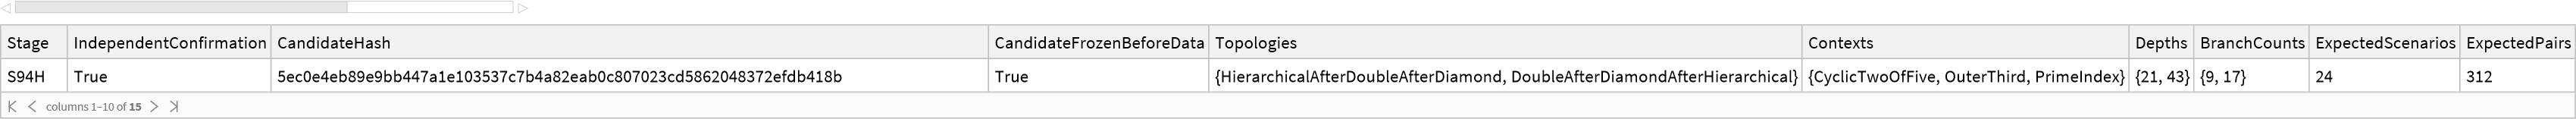

In [285]:
If[!TrueQ[candidateFrozenBeforeConfirmation94H],
Print["S94H blocked: candidate was not frozen before confirmation definitions."];Abort[]];
ClearAll[ConfirmationContextAction94H,ConfirmationCase94H,
HierarchicalAfterDoubleAfterDiamond94H,DoubleAfterDiamondAfterHierarchical94H,
ConfirmationTopologyTransform94H,ConfirmationWorld94H,
ConfirmationPair94H,ConfirmationDefinitionBundle94H];
confirmationTopologies94H={"HierarchicalAfterDoubleAfterDiamond",
"DoubleAfterDiamondAfterHierarchical"};
confirmationContexts94H={"CyclicTwoOfFive","OuterThird","PrimeIndex"};
confirmationDepths94H={21,43};confirmationBranchCounts94H={9,17};
ConfirmationContextAction94H[i_Integer,pattern_String,n_Integer]:=Switch[pattern,
"CyclicTwoOfFive",If[MemberQ[{1,2},Mod[i,5]],"Continue","Stop"],
"OuterThird",If[i<=Ceiling[n/3]||i>Floor[2 n/3],"Continue","Stop"],
"PrimeIndex",If[PrimeQ[i],"Continue","Stop"],_,"Undefined"];
ConfirmationCase94H[depth_Integer,answer_Integer,target_String,
topologyIndex_Integer,contextIndex_Integer,branchCount_Integer,pattern_String]:=
Module[{seed,bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,main,perm,anc,
branchAction,i},seed=94400000+100000 topologyIndex+10000 contextIndex+
100 branchCount+depth;bb=1000000000 seed;K=bb+1;
c=Table[bb+100+i,{i,branchCount}];v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[Table[{DirectedEdge[K,c[[i]]],DirectedEdge[c[[i]],v[[i]]]},{i,branchCount}],1];
Do[ib=bb+20000000 i;m=ib+1;safe=ib+2;u=ib+3;dummy=ib+4;
r1=ib+10;r2=ib+20;wrong=c[[1+Mod[i,branchCount]]];
main=Join[P59[q[[i]],r1,depth,ib+1000000],P59[q[[i]],r2,depth,ib+2000000],
{DirectedEdge[r1,m],DirectedEdge[r2,m]},P59[q[[i]],safe,depth+1,ib+3000000]];
branchAction=If[i===answer,target,ConfirmationContextAction94H[i,pattern,branchCount]];
perm=If[branchAction==="Continue",
{DirectedEdge[m,c[[i]]],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]},
{DirectedEdge[m,wrong],DirectedEdge[safe,c[[i]]],DirectedEdge[u,dummy]}];
anc=Join[A59[m,i,bb+970000000+10000 i],A59[c[[i]],i,bb+980000000+10000 i]];
e=Join[e,main,perm,anc];AppendTo[f,m],{i,branchCount}];{{Union[e],q,K,v,c,f},answer}];
HierarchicalAfterDoubleAfterDiamond94H[c_List]:=
HierarchicalDiamondIn80[DoubleDiamondIn79[DiamondIn72[c]]];
DoubleAfterDiamondAfterHierarchical94H[c_List]:=
DoubleDiamondIn79[DiamondIn72[HierarchicalDiamondIn80[c]]];
ConfirmationTopologyTransform94H[name_String,c_List]:=Switch[name,
"HierarchicalAfterDoubleAfterDiamond",HierarchicalAfterDoubleAfterDiamond94H[c],
"DoubleAfterDiamondAfterHierarchical",DoubleAfterDiamondAfterHierarchical94H[c],_,$Failed];
ConfirmationWorld94H[topology_String,topologyIndex_Integer,context_String,
contextIndex_Integer,depth_Integer,branchCount_Integer,target_String,answer_Integer]:=Module[
{baseCase,topologyCase,canonicalization,canonicalCase,traceSeconds,trace,levels,pack,
vertexList,queryNodes,rawMap,codeMap,slotMap,vector},
baseCase=ConfirmationCase94H[depth,answer,target,topologyIndex,contextIndex,
branchCount,context];topologyCase=ConfirmationTopologyTransform94H[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];pack=Pack60[canonicalCase];vertexList=pack[[12]];
queryNodes=Select[Range[Length[vertexList]],TrueQ[
NodeRole94H[vertexList[[#]],canonicalCase,answer]["QueryBranchRelated"]]&];
rawMap=AssociationThread[vertexList[[queryNodes]],
({Lookup[levels[[3]],#],Lookup[levels[[4]],#]}&)/@queryNodes];
codeMap=AssociationThread[Keys[rawMap],EncodePair94H/@Values[rawMap]];
If[!AssociationQ[codeMap]||!SameQ[Keys[codeMap],Keys[rawMap]]||
!SameQ[Length[codeMap],Length[rawMap]],
Print["S94H blocked: encoded query map failed structural validation."];Abort[]];
slotMap=SemanticAlignedMap94H[codeMap,canonicalCase,answer];vector=SlotRawVector94H[slotMap];
<|"Vector"->vector,"ReferenceAction"->ReferenceAction94H[canonicalCase],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"ContractionCountCorrect"->SameQ[canonicalization["Contractions"],
ExpectedContractions94H[baseCase]],"ProtectedNodesPreserved"->
canonicalization["ProtectedNodesPreserved"],"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],"TraceSeconds"->traceSeconds|>];
ConfirmationPair94H[topology_String,ti_Integer,context_String,ci_Integer,
depth_Integer,n_Integer,answer_Integer]:=Module[{continue,stop,difference,score,reverse},
continue=ConfirmationWorld94H[topology,ti,context,ci,depth,n,"Continue",answer];
stop=ConfirmationWorld94H[topology,ti,context,ci,depth,n,"Stop",answer];
difference=continue["Vector"]-stop["Vector"];
score=N[Total[candidateReloaded94H["Weights"]
(difference/candidateReloaded94H["Scale"])]];reverse=-score;
<|"Topology"->topology,"Context"->context,"Depth"->depth,"BranchCount"->n,
"Answer"->answer,"Score"->score,"ReverseScore"->reverse,
"PairCorrect"->And[score>0,reverse<0],"ZeroScore"->Abs[score]<10^-12,
"ReferenceActionsCorrect"->And[SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]],"WorldsValid"->And[
continue["CanonicalCaseExactlyBase"],stop["CanonicalCaseExactlyBase"],
continue["ContractionCountCorrect"],stop["ContractionCountCorrect"],
continue["ProtectedNodesPreserved"],stop["ProtectedNodesPreserved"],
continue["TerminatedNaturally"],stop["TerminatedNaturally"],
!continue["HitSafetyCap"],!stop["HitSafetyCap"]],
"TraceSeconds"->continue["TraceSeconds"]+stop["TraceSeconds"]|>];
ConfirmationDefinitionBundle94H[]:={DownValues[ConfirmationContextAction94H],
DownValues[ConfirmationCase94H],DownValues[HierarchicalAfterDoubleAfterDiamond94H],
DownValues[DoubleAfterDiamondAfterHierarchical94H],
DownValues[ConfirmationTopologyTransform94H],DownValues[ConfirmationWorld94H],
DownValues[ConfirmationPair94H]};
confirmationDefinitionHashBefore94H=Hash[ConfirmationDefinitionBundle94H[],
"SHA256","HexString"];
confirmationProtocol94H=<|"Stage"->"S94H","IndependentConfirmation"->True,
"CandidateHash"->candidateObjectHash94H,"CandidateFrozenBeforeData"->True,
"Topologies"->confirmationTopologies94H,"Contexts"->confirmationContexts94H,
"Depths"->confirmationDepths94H,"BranchCounts"->confirmationBranchCounts94H,
"ExpectedScenarios"->24,"ExpectedPairs"->312,"ExpectedWorlds"->624,
"PassAccuracy"->0.95,"PassWorstAxisGroupAccuracy"->0.8,
"CandidateSearchPerformed"->False|>;
confirmationProtocolHash94H=Hash[Normal[confirmationProtocol94H],"SHA256","HexString"];
Dataset[{Append[confirmationProtocol94H,"ProtocolHash"->confirmationProtocolHash94H]}]


Dataset[{<|Completed -> 7, Expected -> 24, 
 
>     CompletedScenarioIndices -> {1, 2, 7, 8, 13, 14, 19}, 
 
>     RemainingScenarioIndices -> 
 
>      {3, 4, 5, 6, 9, 10, 11, 12, 15, 16, 17, 18, 20, 21, 22, 23, 24}, 
 
>     CandidateHash -> 5ec0e4eb89e9bb447a1e103537c7b4a82eab0c807023cd5862048372efdb418b, 
 
>     CandidateFileHash -> 
 
>      8cbf7184200c6a04072f9b375af3137534dc3764bff7a32bf57db4a320187e1e, 
 
>     CandidateSearchPerformed -> False, CandidateReexported -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Completed, Expected, CompletedScenarioIndices, 
 
>      RemainingScenarioIndices, CandidateHash, CandidateFileHash, 
 
>      CandidateSearchPerformed, CandidateReexported}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 7], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 17], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
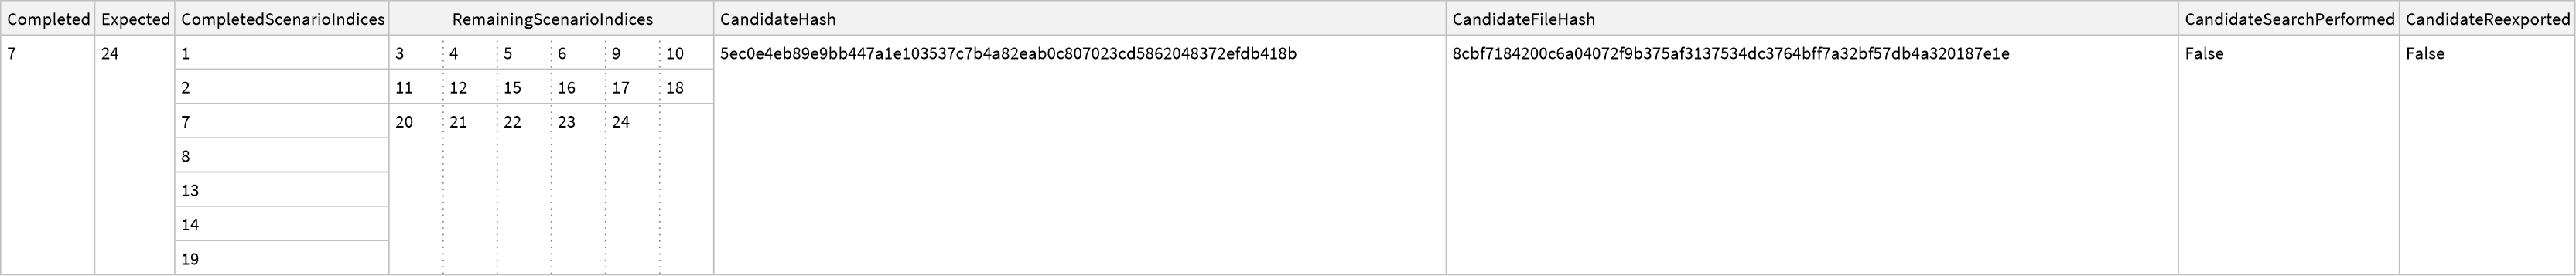

In [306]:
confirmationScenarios94H=Cases[Table[
<|"Topology"->confirmationTopologies94H[[ti]],"TopologyIndex"->ti,
"Context"->confirmationContexts94H[[ci]],"ContextIndex"->ci,
"Depth"->depth,"BranchCount"->n|>,
{ti,Length[confirmationTopologies94H]},
{ci,Length[confirmationContexts94H]},
{depth,confirmationDepths94H},{n,confirmationBranchCounts94H}],_Association,Infinity];
confirmationScenarioShapePassed94H=And[
SameQ[Length[confirmationScenarios94H],24],
VectorQ[confirmationScenarios94H,AssociationQ],
SameQ[Sort@DeleteDuplicates@Lookup[confirmationScenarios94H,"BranchCount"],
Sort@confirmationBranchCounts94H]];
If[!TrueQ[confirmationScenarioShapePassed94H],
Print["S94H R3 blocked: confirmation scenario shape is invalid."];Abort[]];

If[!TrueQ[candidateFrozenBeforeConfirmation94H],
Print["S94H R3 GUI blocked: candidate is not frozen."];Abort[]];
checkpointDirectory94H="E:/engine_wolf/TCCT_S94H_R3_Checkpoints";
If[!DirectoryQ[checkpointDirectory94H],
Quiet@Check[CreateDirectory[checkpointDirectory94H],Null]];
If[!DirectoryQ[checkpointDirectory94H],
Print["S94H R3 GUI blocked: checkpoint directory is unavailable."];Abort[]];

ClearAll[CheckpointObjectValidQ94H,RunCheckpointScenario94H,
CheckpointProgress94H];
CheckpointObjectValidQ94H[obj_,idx_Integer,scenario_Association]:=And[
AssociationQ[obj],SameQ[obj["Stage"],"S94H"],SameQ[obj["HarnessRevision"],3],
SameQ[obj["ScenarioIndex"],idx],SameQ[obj["Scenario"],scenario],
SameQ[obj["CandidateHash"],candidateObjectHash94H],
SameQ[obj["CandidateFileHash"],candidateFileHash94H],
SameQ[obj["ProtocolHash"],confirmationProtocolHash94H],
SameQ[obj["DefinitionHash"],confirmationDefinitionHashBefore94H],
SameQ[obj["PairCount"],scenario["BranchCount"]],
SameQ[obj["WorldCount"],2 scenario["BranchCount"]],
VectorQ[obj["Pairs"],AssociationQ],
SameQ[Length[obj["Pairs"]],scenario["BranchCount"]],
TrueQ[obj["ScenarioValidityPassed"]],
SameQ[obj["CheckpointHash"],Hash[Normal@KeyDrop[obj,{"CheckpointHash"}],
"SHA256","HexString"]]];

CheckpointProgress94H[]:=Module[{paths,done},
paths=FileNameJoin[{checkpointDirectory94H,
"scenario_"<>IntegerString[#,10,2]<>".wxf"}]&/@Range[24];
done=Pick[Range[24],FileExistsQ/@paths,True];
<|"Completed"->Length[done],"Expected"->24,"CompletedScenarioIndices"->done,
"RemainingScenarioIndices"->Complement[Range[24],done],
"CandidateHash"->candidateObjectHash94H,
"CandidateFileHash"->candidateFileHash94H,
"CandidateSearchPerformed"->False,"CandidateReexported"->False|>];

RunCheckpointScenario94H[idx_Integer]:=Module[
{scenario,path,existing,elapsed,pairs,validity,payload,checkpoint,
exportResult,reloaded,result},
If[!MemberQ[Range[24],idx],Return[<|"ScenarioIndex"->idx,
"Status"->"INVALID_SCENARIO_INDEX"|>]];
scenario=confirmationScenarios94H[[idx]];
path=FileNameJoin[{checkpointDirectory94H,
"scenario_"<>IntegerString[idx,10,2]<>".wxf"}];
If[FileExistsQ[path]&&FileByteCount[path]>0,
existing=Quiet@Check[Import[path,"WXF"],$Failed];
If[TrueQ[CheckpointObjectValidQ94H[existing,idx,scenario]],
Return[<|"ScenarioIndex"->idx,"Scenario"->scenario,
"Status"->"VALID_CHECKPOINT_REUSED","PairCount"->existing["PairCount"],
"ElapsedSeconds"->existing["ElapsedSeconds"],
"CheckpointHash"->existing["CheckpointHash"],
"Progress"->CheckpointProgress94H[]|>],
Print["S94H R3 GUI blocked: existing checkpoint failed validation: ",path];Abort[]]];
{elapsed,pairs}=AbsoluteTiming[Table[ConfirmationPair94H[
scenario["Topology"],scenario["TopologyIndex"],scenario["Context"],
scenario["ContextIndex"],scenario["Depth"],scenario["BranchCount"],answer],
{answer,scenario["BranchCount"]}]];
validity=And[VectorQ[pairs,AssociationQ],
SameQ[Length[pairs],scenario["BranchCount"]],
And@@Lookup[pairs,"ReferenceActionsCorrect",False],
And@@Lookup[pairs,"WorldsValid",False],
And@@Map[Abs[#Score+#ReverseScore]<10^-12&,pairs]];
If[!TrueQ[validity],
Print["S94H R3 GUI blocked: scenario validity failed before export: ",idx];Abort[]];
payload=<|"Stage"->"S94H","HarnessRevision"->3,
"ExecutionMode"->"CheckpointedResumableGUI","ScenarioIndex"->idx,
"Scenario"->scenario,"Pairs"->pairs,"PairCount"->Length[pairs],
"WorldCount"->2 Length[pairs],"ElapsedSeconds"->elapsed,
"ScenarioValidityPassed"->validity,"CandidateHash"->candidateObjectHash94H,
"CandidateFileHash"->candidateFileHash94H,
"ProtocolHash"->confirmationProtocolHash94H,
"DefinitionHash"->confirmationDefinitionHashBefore94H,
"CandidateSearchPerformed"->False,"CandidateReexported"->False|>;
checkpoint=Append[payload,"CheckpointHash"->
Hash[Normal[payload],"SHA256","HexString"]];
exportResult=Quiet@Check[Export[path,checkpoint,"WXF"],$Failed];
If[!StringQ[exportResult]||!FileExistsQ[path]||FileByteCount[path]<=0,
Print["S94H R3 GUI blocked: checkpoint export failed: ",idx];Abort[]];
reloaded=Quiet@Check[Import[path,"WXF"],$Failed];
If[!TrueQ[CheckpointObjectValidQ94H[reloaded,idx,scenario]],
Print["S94H R3 GUI blocked: checkpoint reload validation failed: ",idx];Abort[]];
result=<|"ScenarioIndex"->idx,"Scenario"->scenario,
"Status"->"CHECKPOINT_EXPORTED","PairCount"->Length[pairs],
"ElapsedSeconds"->elapsed,"CheckpointHash"->checkpoint["CheckpointHash"],
"Progress"->CheckpointProgress94H[]|>;
result];

Dataset[{CheckpointProgress94H[]}]


In [322]:
Dataset[{RunCheckpointScenario94H[1]}]


S94H R3 GUI blocked: existing checkpoint failed validation: 
 
>   E:\engine_wolf\TCCT_S94H_R3_Checkpoints\scenario_01.wxf


$Aborted

In [327]:
Dataset[{RunCheckpointScenario94H[2]}]


S94H R3 GUI blocked: existing checkpoint failed validation: 
 
>   E:\engine_wolf\TCCT_S94H_R3_Checkpoints\scenario_02.wxf


$Aborted

Dataset[{<|ScenarioIndex -> 3, Scenario -> 
 
>      <|Topology -> HierarchicalAfterDoubleAfterDiamond, TopologyIndex -> 1, 
 
>       Context -> CyclicTwoOfFive, ContextIndex -> 1, Depth -> 43, BranchCount -> 9|>, 
 
>     Status -> CHECKPOINT_EXPORTED, PairCount -> 9, ElapsedSeconds -> 52.6232, 
 
>     CheckpointHash -> 
 
>      c5423de407cb7463a732b7239ac036e32ac9482acdd618d5d9a757b7b71ffa85, 
 
>     Progress -> 
 
>      <|Completed -> 8, Expected -> 24, 
 
>       CompletedScenarioIndices -> {1, 2, 3, 7, 8, 13, 14, 19}, 
 
>       RemainingScenarioIndices -> 
 
>        {4, 5, 6, 9, 10, 11, 12, 15, 16, 17, 18, 20, 21, 22, 23, 24}, 
 
>       CandidateHash -> 
 
>        5ec0e4eb89e9bb447a1e103537c7b4a82eab0c807023cd5862048372efdb418b, 
 
>       CandidateFileHash -> 
 
>        8cbf7184200c6a04072f9b375af3137534dc3764bff7a32bf57db4a320187e1e, 
 
>       CandidateSearchPerformed -> False, CandidateReexported -> False|>|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{ScenarioIndex, Scenario, Status, PairCount, 
 
>      ElapsedSeconds, CheckpointHash, Progress}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Struct[{Topology, TopologyIndex, Context, 
 
>        ContextIndex, Depth, BranchCount}, 
 
>       {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[String], 
 
>        TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Atom[String], TypeSystem`Struct[{Completed, Expected, 
 
>        CompletedScenarioIndices, RemainingScenarioIndices, CandidateHash, 
 
>        CandidateFileHash, CandidateSearchPerformed, CandidateReexported}, 
 
>       {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>        TypeSystem`Vector[TypeSystem`Atom[Integer], 8], 
 
>        TypeSystem`Vector[TypeSystem`Atom[Integer], 16], TypeSystem`Atom[String], 
 
>        TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>        TypeSystem`Atom[TypeSystem`Boolean]}]}], 1], <||>]
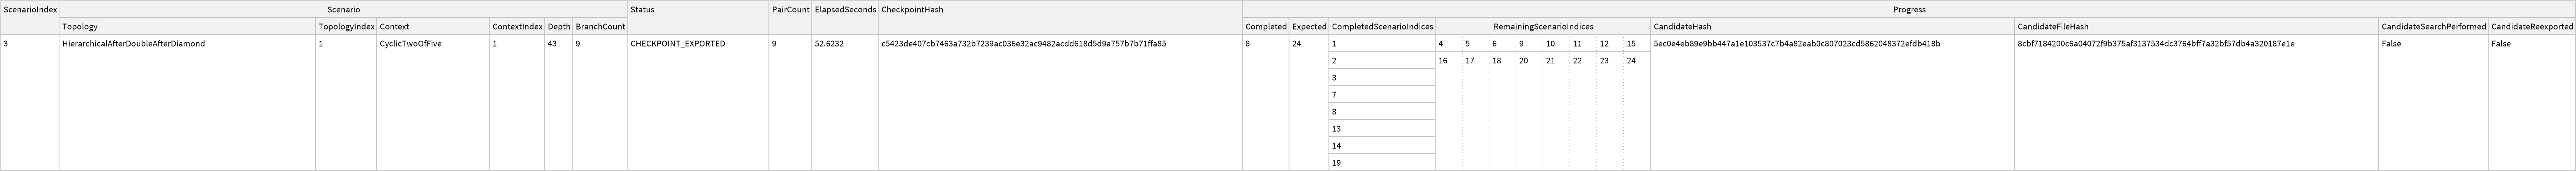

In [332]:
Dataset[{RunCheckpointScenario94H[3]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[4]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[5]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[6]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[7]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[8]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[9]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[10]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[11]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[12]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[13]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[14]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[15]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[16]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[17]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[18]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[19]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[20]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[21]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[22]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[23]}]


In [ ]:
Dataset[{RunCheckpointScenario94H[24]}]


In [ ]:
If[!TrueQ[candidateFrozenBeforeConfirmation94H],
Print["S94H R3 merge blocked: candidate is not frozen."];Abort[]];
checkpointDirectory94H="E:/engine_wolf/TCCT_S94H_R3_Checkpoints";
checkpointPaths94H=FileNameJoin[{checkpointDirectory94H,
"scenario_"<>IntegerString[#,10,2]<>".wxf"}]&/@Range[24];
If[!And@@Map[FileExistsQ[#]&&FileByteCount[#]>0&,checkpointPaths94H],
Print["S94H R3 merge blocked: one or more checkpoints are missing."];
Dataset[MapIndexed[<|"ScenarioIndex"->First[#2],"Exists"->FileExistsQ[#1],
"Bytes"->If[FileExistsQ[#1],FileByteCount[#1],0]|>&,checkpointPaths94H]];Abort[]];
checkpoints94H=Quiet@Check[Import[#,"WXF"]&/@checkpointPaths94H,$Failed];
If[!ListQ[checkpoints94H]||!VectorQ[checkpoints94H,AssociationQ],
Print["S94H R3 merge blocked: checkpoint import failed."];Abort[]];
checkpointValidationRows94H=MapThread[Function[{obj,scenario,idx},<|
"ScenarioIndex"->idx,"Association"->AssociationQ[obj],
"IndexMatched"->SameQ[obj["ScenarioIndex"],idx],
"ScenarioMatched"->SameQ[obj["Scenario"],scenario],
"CandidateMatched"->SameQ[obj["CandidateHash"],candidateObjectHash94H],
"CandidateFileMatched"->SameQ[obj["CandidateFileHash"],candidateFileHash94H],
"ProtocolMatched"->SameQ[obj["ProtocolHash"],confirmationProtocolHash94H],
"DefinitionMatched"->SameQ[obj["DefinitionHash"],confirmationDefinitionHashBefore94H],
"PairCountMatched"->SameQ[obj["PairCount"],scenario["BranchCount"]],
"ScenarioValidityPassed"->TrueQ[obj["ScenarioValidityPassed"]],
"CheckpointHashMatched"->SameQ[obj["CheckpointHash"],
Hash[Normal@KeyDrop[obj,{"CheckpointHash"}],"SHA256","HexString"]]|>],
{checkpoints94H,confirmationScenarios94H,Range[24]}];
checkpointSetValidityPassed94H=And@@Flatten[
Values[KeyDrop[#,{"ScenarioIndex"}]]&/@checkpointValidationRows94H];
If[!TrueQ[checkpointSetValidityPassed94H],
Print["S94H R3 merge blocked: checkpoint set validation failed."];
Dataset[checkpointValidationRows94H];Abort[]];

confirmationPairs94H=Flatten[Lookup[checkpoints94H,"Pairs"],1];
axisGroups94H=Flatten[Map[Function[axis,Map[Function[value,Module[{rows},
rows=Select[confirmationPairs94H,SameQ[Lookup[#,axis],value]&];
<|"Axis"->axis,"Value"->ToString[value],"Pairs"->Length[rows],
"Correct"->Count[rows,p_/;TrueQ[p["PairCorrect"]]],
"Accuracy"->N[Count[rows,p_/;TrueQ[p["PairCorrect"]]]/Length[rows]],
"MinimumMargin"->Min[Lookup[rows,"Score"]]|>]],DeleteDuplicates@Lookup[
confirmationPairs94H,axis]]],{"Topology","Context","Depth","BranchCount","Answer"}],1];
confirmationAccuracy94H=N[Count[confirmationPairs94H,p_/;TrueQ[p["PairCorrect"]]]/
Length[confirmationPairs94H]];
confirmationWorstGroupAccuracy94H=Min@Lookup[axisGroups94H,"Accuracy"];
confirmationValidityPassed94H=And[TrueQ[checkpointSetValidityPassed94H],
SameQ[Length[confirmationScenarios94H],24],SameQ[Length[confirmationPairs94H],312],
SameQ[Total@Lookup[checkpoints94H,"WorldCount"],624],
SameQ[Count[confirmationPairs94H,p_/;TrueQ[p["ReferenceActionsCorrect"]]],312],
SameQ[Count[confirmationPairs94H,p_/;TrueQ[p["WorldsValid"]]],312],
SameQ[Count[confirmationPairs94H,p_/;TrueQ[p["ZeroScore"]]],0],
And@@Map[Abs[#Score+#ReverseScore]<10^-12&,confirmationPairs94H]];
confirmationCriterionPassed94H=And[confirmationValidityPassed94H,
confirmationAccuracy94H>=0.95,confirmationWorstGroupAccuracy94H>=0.8];

modelHashAfter94H=Hash[Normal[frozen75D],"SHA256","HexString"];
coreHashAfter94H=Hash[CoreDefinitionBundle94H[],"SHA256","HexString"];
candidateHashAfter94H=Hash[Normal@KeyDrop[candidateReloaded94H,{"CandidateHash"}],
"SHA256","HexString"];
confirmationDefinitionHashAfter94H=Hash[ConfirmationDefinitionBundle94H[],
"SHA256","HexString"];
fileHashesAfter94H=FileSHA256Hex94H/@requiredFiles94H;
integrityPassed94H=And[SameQ[modelHashBefore94H,modelHashAfter94H],
SameQ[coreHashBefore94H,coreHashAfter94H],
SameQ[fileHashesBefore94H,fileHashesAfter94H],
SameQ[candidateHashAfter94H,candidateObjectHash94H],
SameQ[confirmationDefinitionHashBefore94H,confirmationDefinitionHashAfter94H]];
resultPayload94H=<|"Stage"->"S94H","Name"->"IndependentFullQueryConfirmation",
"IndependentConfirmation"->True,"BlindTest"->False,"HarnessRevision"->3,
"HarnessCorrections"->{"ScenarioEnumerationAssociationExtraction",
"AssociationValueMappingPreservingKeys","CheckpointedProtocolEquivalentExecution"},
"ExecutionMode"->"CheckpointedResumableGUI","CheckpointCount"->24,
"CheckpointSetValidityPassed"->checkpointSetValidityPassed94H,
"CandidateFrozenBeforeConfirmation"->candidateFrozenBeforeConfirmation94H,
"CandidateRecoveredAfterHarnessError"->candidateRecoveredAfterHarnessError94H,
"CandidateSearchPerformed"->False,"CandidateReexported"->False,
"CandidateHash"->candidateObjectHash94H,"CandidateFileHash"->candidateFileHash94H,
"Representation"->"SlotRaw12","Family"->"Centroid",
"Scenarios"->Length[confirmationScenarios94H],"Pairs"->Length[confirmationPairs94H],
"Worlds"->Total@Lookup[checkpoints94H,"WorldCount"],
"CorrectPairs"->Count[confirmationPairs94H,p_/;TrueQ[p["PairCorrect"]]],
"Accuracy"->confirmationAccuracy94H,
"WorstAxisGroupAccuracy"->confirmationWorstGroupAccuracy94H,
"MinimumMargin"->Min@Lookup[confirmationPairs94H,"Score"],
"ZeroScores"->Count[confirmationPairs94H,p_/;TrueQ[p["ZeroScore"]]],
"TotalScenarioSeconds"->Total@Lookup[checkpoints94H,"ElapsedSeconds"],
"AxisGroups"->axisGroups94H,
"ConfirmationValidityPassed"->confirmationValidityPassed94H,
"ConfirmationCriterionPassed"->confirmationCriterionPassed94H,
"IntegrityPassed"->integrityPassed94H,"CandidateFrozen"->True,
"CoreChanged"->!SameQ[coreHashBefore94H,coreHashAfter94H],
"OriginalFrozenModelChanged"->!SameQ[modelHashBefore94H,modelHashAfter94H],
"DeduplicationMechanismChanged"->False,"UndirectedFreezeMechanismChanged"->False,
"ProtocolHash"->confirmationProtocolHash94H,
"ConfirmationDefinitionHash"->confirmationDefinitionHashBefore94H,
"Outcome"->Which[!TrueQ[integrityPassed94H],"S94H_INTEGRITY_FAILURE",
!TrueQ[confirmationValidityPassed94H],"S94H_INVALID_CONFIRMATION",
TrueQ[confirmationCriterionPassed94H],"S94H_INDEPENDENT_CONFIRMATION_PASS",
True,"S94H_INDEPENDENT_CONFIRMATION_FAIL"]|>;
resultHash94H=Hash[Normal[resultPayload94H],"SHA256","HexString"];
certificate94H=Append[resultPayload94H,"ResultHash"->resultHash94H];
exportResult94H=Quiet@Check[Export[resultCertificatePath94H,certificate94H,"RawJSON"],$Failed];
certificateExported94H=StringQ[exportResult94H]&&FileExistsQ[resultCertificatePath94H]&&
FileByteCount[resultCertificatePath94H]>0;
If[!TrueQ[certificateExported94H],
Print["S94H R3 merge failed to export the final certificate."];Abort[]];
Print[<|"Stage"->"S94H","HarnessRevision"->3,
"CertificateExported"->certificateExported94H,
"Scenarios"->certificate94H["Scenarios"],"Pairs"->certificate94H["Pairs"],
"Worlds"->certificate94H["Worlds"],"Accuracy"->certificate94H["Accuracy"],
"WorstAxisGroupAccuracy"->certificate94H["WorstAxisGroupAccuracy"],
"ConfirmationValidityPassed"->certificate94H["ConfirmationValidityPassed"],
"ConfirmationCriterionPassed"->certificate94H["ConfirmationCriterionPassed"],
"IntegrityPassed"->certificate94H["IntegrityPassed"],
"CoreChanged"->certificate94H["CoreChanged"],
"CandidateSearchPerformed"->certificate94H["CandidateSearchPerformed"],
"CandidateReexported"->certificate94H["CandidateReexported"],
"Outcome"->certificate94H["Outcome"],"ResultHash"->resultHash94H|>];
